In [1]:
from torch.utils.data import Dataset,DataLoader
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import WeightedRandomSampler
import torch.nn.functional as F
import cv2
import torch
import random
import os
import zarr
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm
from pathlib import Path
import torch.nn as nn
import copy
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from skimage.morphology import skeletonize
import seaborn as sns
import json
import matplotlib.patches as mpatches
import datetime
import shutil
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from albumentations.core.transforms_interface import ImageOnlyTransform
from skimage.filters import frangi , hessian , meijering
from torchvision.models.swin_transformer import (
swin_t,swin_s,swin_b,
swin_v2_t,swin_v2_s,swin_v2_b,
Swin_S_Weights,Swin_V2_S_Weights,
Swin_B_Weights,Swin_V2_B_Weights,
Swin_T_Weights,Swin_V2_T_Weights
)
from transformers import AutoModelForSemanticSegmentation
from torchvision.ops.focal_loss import sigmoid_focal_loss
from monai.losses import FocalLoss
from sklearn.metrics import accuracy_score

In [2]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:
import torch
# torch.autograd.set_detect_anomaly(True)
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
import torch.nn.functional as F
from torchvision.transforms import v2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np

# dataset

In [3]:
class ToTensor:
    def __init__(slef):
        pass
    def __call__(self,x):
        if(len(x.shape)==2):
            x = x[...,None]
        x = torch.from_numpy(x)
        x = x.permute(2,0,1)
        return x
class UnetDataset(Dataset):
    def __init__(self,transform,data,crop_prob=0.33,base_size=512,
                 valid=False,out_counts=1,just_binary_trining=True,binary_type="both"):
        super(UnetDataset,self).__init__()
        self.data = data
        self.transform = transform
        self.base_size=base_size
        self.valid=valid
        self.crop_prob = crop_prob
        self.just_binary_trining=just_binary_trining
        self.to_tensor = ToTensor()
        self.dsv_transforms = [
            A.Resize(
                base_size[0]//(2**i), 
                base_size[1]//(2**i), 
                interpolation=cv2.INTER_NEAREST
            ) for i in range(1,out_counts)
        ]
        self.binary_type = binary_type
    def __len__(self):
        return len(self.data)
    def __getitem__(self,index):
        img, multi_mask ,binary_mask,bbox,name_stem= self.data[index]
        if(not self.valid):
            if(random.random()<self.crop_prob ):
                img, multi_mask ,binary_mask= crop_with_bbox(
                    img, multi_mask ,  binary_mask,bbox
                )
        # img = np.expand_dims(img, axis=-1) 
        multi_mask = multi_mask[...,None]
        binary_mask = binary_mask[...,None]
        result = self.transform(
            image=img,
            mask=multi_mask,
            binary_mask = binary_mask
        )
        
        new_image = result['image']
        new_multi_mask = result["mask"]
        new_binary_mask = result["binary_mask"]

        masks = []
        if(self.just_binary_trining):
            mask = new_binary_mask
        else:
            mask = new_multi_mask
        for i,resizer in enumerate(self.dsv_transforms):
            resized = self.to_tensor(
                resizer(image=mask)["image"]
            ).long()
            # print(resized.shape)
            masks.append(resized)
        
        masks = [
            self.to_tensor(mask).long()
        ] + masks
        new_image = self.to_tensor(new_image)
        # new_image = self.to_tensor(image = new_image)["image"]
        return (
            new_image.float() ,
            masks
        )

class ValidUnetDataset(Dataset):
    def __init__(self,transform,data):
        super(ValidUnetDataset,self).__init__()
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self,index):
        img,side_label,binary_mask,abs_mask,mask = self.data[index]
        # img = np.expand_dims(img, axis=-1) 
        mask = mask[...,None]
        binary_mask = binary_mask[...,None]
        abs_mask = abs_mask[...,None]

        result = self.transform(
            image=img,
            mask=mask,
            binary_mask = binary_mask,
            abs_mask = abs_mask
        )
        new_image = result['image']
        new_mask = result['mask'].squeeze(-1)
        new_abs_mask = result["abs_mask"].squeeze(-1)
        new_binary_mask = result["binary_mask"].squeeze(-1)

        new_binary_mask = new_binary_mask.long()
        new_abs_mask = new_abs_mask.long()
        new_mask = new_mask.long()

        # new_image = self.to_tensor(image = new_image)["image"]
        return new_image.float() , side_label ,new_binary_mask , new_abs_mask , new_mask

class UnetExampleDataset(Dataset):
    def __init__(self,transform,data,base_transform=None):
        super(UnetExampleDataset,self).__init__()
        
        self.data = data
        self.transform = transform
        self.to_tensor = ToTensorV2()
        if(base_transform is None):
            self.base_transform = A.Compose(
                [ToTensorV2()]
            )
        else:
            self.base_transform = base_transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self,index):
        img,side_label,binary_mask,abs_mask,mask = self.data[index]
        # img = np.expand_dims(img, axis=-1) 
        # print(img.shape)
        mask = mask[...,None]
        binary_mask = binary_mask[...,None]
        abs_mask = abs_mask[...,None]
        
        result = self.transform(
            image=img,
            mask=mask,
            binary_mask = binary_mask,
            abs_mask = abs_mask
        )
        new_image = result['image']
        new_mask = result['mask'].squeeze(-1)
        new_abs_mask = result["abs_mask"].squeeze(-1)
        new_binary_mask = result["binary_mask"].squeeze(-1)
        
        raw_result = self.base_transform(
            image=img,
            mask=mask,
            binary_mask = binary_mask,
            abs_mask = abs_mask
        )
        raw_image = raw_result['image']
        raw_mask = raw_result['mask'].squeeze(-1)
        raw_abs_mask = raw_result["abs_mask"].squeeze(-1)
        raw_binary_mask = raw_result["binary_mask"].squeeze(-1)
        new_image = self.to_tensor(image = new_image)["image"]
        return new_image.float() , new_mask  , raw_image.float() , raw_mask
    
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

# helpers

In [4]:
@torch.no_grad()
def read_images(base_path, part,preprocessor,in_c,resize_binary,
                max_workers=None,train_class_counts=None,k=40,
                just_binary_trining=False,resizer=None,rare=None,
               data_path = "./data"):
    base_path = Path(base_path)
    images_base = base_path / "images" / part
    labels_base = base_path / "labels" / part
    skels_base = base_path / "skels" / part
    transformed_base = base_path / "transformed" / part
    
    with open(f"{data_path}/{part}_side_labels.json","r") as f:
        side_labels = json.load(f)
    with open(f"{data_path}/{part}_fg_bboxes.json","r") as f:
        bboxes = json.load(f)
    with open(f"{data_path}/{part}.json","r") as f:
        metadata = json.load(f)
    if(train_class_counts is not None):
        freqs = train_class_counts / train_class_counts.sum()
        class_w = 1 / (freqs + 1e-6)
        class_w[0] = 0
    image_names = sorted([p.name for p in os.scandir(images_base) if p.is_file()])
    if(train_class_counts is not None):
        max_count = np.max(train_class_counts[1:])
        print("max count is : ",max_count)
    if(not preprocessor):
        print("NOTE : preprocessor is not defined . no preprocessing will be used !")
    def _read_one(fname):
        name_stem = Path(fname).stem
        img_path = images_base / fname
        label_path = labels_base / f"{name_stem}.zarr"
        t_img_path = transformed_base / f"{name_stem}.zarr"
        skel_path = skels_base / fname
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        # t_img = zarr.load(t_img_path)
        if(preprocessor):
            for p in preprocessor:
                img = p(img)

        if(in_c!=1):
            # img = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
            img = np.stack([img, img, img], axis=-1)
            # t_img = np.stack([t_img, t_img, t_img], axis=-1)*255

        label = zarr.load(str(label_path))
        if(train_class_counts is not None):
            num_classes = class_w.shape[0]
            counts = np.bincount(label.reshape(-1), minlength=num_classes)
            weight = float((counts * class_w).sum())
        else:
            weight = None

        unique_labels = np.unique(label)
        unique_labels = unique_labels[unique_labels!=0]

        binary_label = (label!=0).astype(np.uint8)
        side_label = side_labels[name_stem]
        bbox = bboxes[name_stem]
        all_bboxes = metadata[name_stem]["bbox_norm"]
        all_labels = metadata[name_stem]["labels"]
        return img, label ,binary_label,bbox, weight , side_label , all_bboxes , all_labels , name_stem

    if max_workers is None:
        cpu = os.cpu_count() or 4
        max_workers = min(32, cpu * 4)

    results = []
    weights = []
    ls=[]
    co=0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for img, label ,binary_label,bbox, weight , side_label , all_bboxes , all_labels , name_stem  in tqdm(ex.map(_read_one, image_names), total=len(image_names)):
            if(part=="train" and resizer is not None):
                current_results , current_weights ,flag=crop_around_rare(
                    img, 
                    label ,
                    binary_label,
                    bbox, 
                    weight , 
                    side_label ,
                    all_bboxes , 
                    all_labels,
                    name_stem,
                    rare,
                    resizer
                )
                if(flag):
                    ls.append(name_stem)
                co+=flag
            else:
                current_results = [[img, label ,binary_label,bbox,name_stem]]
                current_weights = [weight]
            results+=current_results
            weights+=current_weights

    print("f",co)

    if(train_class_counts is not None):
        weights = torch.tensor(weights).double()
        weights +=1e-8
        weights /=weights.sum()
        return results , weights
    else:
        return results
    
def crop_around_rare(img, label ,binary_label,bbox, weight , side_label ,all_bboxes , all_labels,name_stem,rare_labels,resizer):
    current_results = [[img, label ,binary_label,bbox,name_stem]]
    current_weights = [weight]
    flag=0
    for i,l in enumerate(all_labels):
        if l in rare_labels:
            rx_up = all_bboxes[i][0]
            ry_up = all_bboxes[i][1]
            rx_down = rx_up + all_bboxes[i][2]
            ry_down = ry_up + all_bboxes[i][3]

            tx_up = bbox[0]
            ty_up = bbox[1]
            tx_down = bbox[2]
            ty_down = bbox[3]

            x_up_margin = (rx_up - tx_up)//2
            y_up_margin = (ry_up - ty_up)//2
            x_down_margin = (tx_down - rx_down)//2
            y_down_margin = (ty_down - ry_down)//2

            rx_up = int(max(0,rx_up - x_up_margin))
            ry_up = int(max(0,ry_up - y_up_margin))
            rx_down = int(min(tx_down,rx_down + x_down_margin))
            ry_down = int(min(ty_down,ry_down + y_down_margin))
    
            # res = resizer(
            #     image=img[ry_up:ry_down,rx_up:rx_down,None],
            #     mask=label[ry_up:ry_down,rx_up:rx_down,None],
            #     binary_mask = binary_label[ry_up:ry_down,rx_up:rx_down,None]
            # )
            new_img = np.zeros_like(img)
            new_binary_label = np.zeros_like(binary_label)
            new_label = np.zeros_like(label)
            
            new_img[ry_up:ry_down,rx_up:rx_down] = img[ry_up:ry_down,rx_up:rx_down]
            new_binary_label[ry_up:ry_down,rx_up:rx_down]=binary_label[ry_up:ry_down,rx_up:rx_down]
            new_label[ry_up:ry_down,rx_up:rx_down]=label[ry_up:ry_down,rx_up:rx_down]

            
            current_results += [[new_img.copy(), new_label.copy() ,new_binary_label.copy(),[0,0,511,511],name_stem]]
            current_weights += [weight]
            flag=1
    
    return current_results,current_weights,flag

def to_device(img,gt_mask,device,binary_mode):
    gt_mask = gt_mask.long()
    img = img.to(device)
    gt_mask = gt_mask.to(device)
    if(binary_mode):
        gt_label = gt_label.to(device)
    else :
        gt_label = None
    return img , gt_mask 


def crop_dims(target , current):
    left = (current.shape[3]-target.shape[3])//2
    right = (current.shape[3]-target.shape[3]) - left
    top = (current.shape[2]-target.shape[2])//2
    down = (current.shape[2]-target.shape[2]) - top
    croped = current[:,:,top:-down , left:-right]
    return croped

def padd_dims(target , current):
    pad_h = target.shape[2] - current.shape[2] 
    pad_w = target.shape[3] - current.shape[3]
    padded = F.pad(current, (0, pad_w, 0, pad_h), mode='constant', value=0)
    return padded

@torch.no_grad()
def TP_TN_FP_FN(preds,gt,process_preds=True,return_TN=False):
    if(process_preds):
        preds_argmax = torch.argmax(preds,dim=1)
        onehot_preds = F.one_hot(preds_argmax,num_classes=preds.shape[1])
        pred_onehot = onehot_preds.permute(0, 3, 1, 2).float()
    else :
        pred_onehot = preds
    
    onehot_gt = F.one_hot(gt,num_classes=preds.shape[1])
    onehot_gt = onehot_gt.permute(0, 3, 1, 2).float()
    TN = 0
    if(return_TN):
        TN = (((1-onehot_gt)*(1-pred_onehot)).sum(dim=(0,2,3))).cpu()
    TP = ((onehot_gt*pred_onehot).sum(dim=(0,2,3))).cpu()
    
    FP = (((1-onehot_gt)*pred_onehot).sum(dim=(0,2,3))).cpu()
    FN = ((onehot_gt*(1-pred_onehot)).sum(dim=(0,2,3))).cpu()
    return TP , TN , FP , FN

def to_rgb(img):
    if(isinstance(img,np.ndarray)):
        img = torch.from_numpy(img)
    x_disp = (img- img.min()) / (img.max() - img.min() + 1e-8)
    
    img = torch.cat([x_disp,x_disp,x_disp],dim=0) *255
    # print("d",img.shape)
    img = img.permute(1,2,0)
    return img.numpy()
def denorm(img,mean,std):
    if(isinstance(img,np.ndarray)):
        img = torch.from_numpy(img)
    img = (img*std) + mean
    img = img.clamp(0,1)*255
    return img.permute(1,2,0).cpu().numpy().astype(np.uint8)

def draw_mask(image,mask,args=None,colors=None):
    img = image.copy().astype(np.uint8)
    m = mask.astype(np.int64)
    if(colors is None):
        colors = np.array([(0,255,0)]*25,dtype=np.uint8)
        c = np.array([(0,255,0)])
        
    else:
        
        c = colors[m[m>0]-1].reshape(-1,3)
        
    # print("----")
    # print(c.shape)
    # print(img[m>0].shape)
    img[m>0] = c
    # print(img.shape)
    return img

@torch.no_grad()
def plot_some_images(data,transforms,mean,std,image_counts=36,fig_shape=(6,6),
                     base_transforms=None):
    ds = UnetExampleDataset(transform=transforms , data=data,base_transform=base_transforms)
    dataloader = DataLoader(
        ds,
        batch_size = 2 ,
        num_workers = 4 ,
        pin_memory=False,
        shuffle=True
    )

    iter_loader = iter(dataloader)
    w,h=fig_shape
    plt.figure(figsize=(w*5,h*5))
    for i in range(1,image_counts+1,2):
        new_imgs , new_mask , old_imgs , old_mask = next(iter_loader)
   
        new_img = new_imgs[0]
        old_img = old_imgs[0]
        if(new_img.shape[0]==1):
            new_img = to_rgb(new_img)
            old_img = to_rgb(old_img)

        else:
            new_img = denorm(new_img,mean,std)
            old_img = denorm(old_img,mean,std)

        # print(old_img.min(),old_img.max())
        # print(new_img.min(),new_img.max())
        # print("--------------")
        new_img = draw_mask(new_img,new_mask[0].numpy())
        
        # print(old_img.min(),old_img.max())
        plt.subplot(w,h,i)
        plt.imshow(old_img)
        plt.title("Old Image")

        plt.subplot(w,h,i+1)
        plt.imshow(new_img)
        plt.title("New Image")

def pre_hard_skeletonize(base_path,output_path):
    parts = ["train","val","test"]
    os.makedirs(os.path.join(output_path , "skels"),exist_ok=True)
    for part in parts:
        mask_base_path = os.path.join(base_path,"labels",part)
        os.makedirs(os.path.join(output_path , "skels",part),exist_ok=True)

        mask_list = os.listdir(mask_base_path)
        for mask_name in tqdm(mask_list):
            name = Path(mask_name).stem
            mask_path = os.path.join(mask_base_path,mask_name)

            mask = zarr.load(str(mask_path))
       
            mask = (mask!=0).astype(np.uint8)
        
            out_skel_path = os.path.join(output_path,"skels",part,f"{name}.png")
            skel = skeletonize(mask).astype(np.uint8) * 255
            cv2.imwrite(out_skel_path,skel)
@torch.no_grad()
def pre_soft_skeletonize(base_path,output_path,batch_size=10,k=25):
    parts = ["train","val","test"]
    os.makedirs(os.path.join(output_path , "skels_soft"),exist_ok=True)
    for part in parts:
        mask_base_path = os.path.join(base_path,"labels",part)
        os.makedirs(os.path.join(output_path , "skels_soft",part),exist_ok=True)

        mask_list = os.listdir(mask_base_path)
        mask_buffer = []
        name_buffer = []
        for i,mask_name in enumerate(tqdm(mask_list)):
            name = Path(mask_name).stem
            mask_path = os.path.join(mask_base_path,mask_name)
            mask = zarr.load(str(mask_path))
            mask = (mask!=0).astype(np.float32)

            mask = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)
            mask_buffer.append(mask)
            name_buffer.append(name)
            if((i+1)%batch_size==0 or i==len(mask_list)-1):
                mask_buffer = torch.cat(mask_buffer,dim=0).to("cuda")
                skels = soft_skeletonize(mask_buffer,k=k)
                skels = skels.cpu().numpy()
                B = skels.shape[0]
                for i in range(B):
                    skel = skels[i,0].astype(np.uint8)*255
                    o_name = name_buffer[i]
                    out_skel_path = os.path.join(
                        output_path,"skels_soft",part,f"{o_name}.png")
                    cv2.imwrite(out_skel_path,skel)
                mask_buffer = []
                name_buffer = []

@torch.no_grad()
def compute_confution_matrix(data_loader,model,class_maps,output_folder_path=None,draw_plot = True,class_count=26,use_amp=False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    conf_mat = torch.zeros((class_count,class_count))
    model.eval()
    for img, masks in data_loader:
        img = img.to(device)
        with torch.autocast(device_type=device,dtype=torch.float16,enabled=use_amp):
            mask = masks[0].to(device).view(-1)
            pred_masks = model(img)[0]

        pred_mask = torch.argmax(pred_masks,dim=1).view(-1)
        encoded_results = (mask*class_count + pred_mask).cpu()
        counts = torch.bincount(encoded_results,minlength=class_count**2).view(class_count,class_count)
        conf_mat += counts
        
    conf_mat = conf_mat.float() / conf_mat.sum(dim=1,keepdims=True).clamp(min=1)
    conf_mat = conf_mat.numpy()
    if(draw_plot):
        class_names = ["background" for i in range(class_count)]
        for index , name in class_maps.items():
            class_names[index] = name
        plt.figure(figsize=(20,20))
        ax = sns.heatmap(
            conf_mat,
            annot=True,
            fmt=".2f",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues"
        )
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        ax.set_title("Confusion Matrix")
        plt.tight_layout()
        if(output_folder_path):
            out_path = os.path.join(output_folder_path,"conf_mat.png")
            plt.savefig(out_path)
    return conf_mat

def erode(mask):
    h_pool = -F.max_pool2d(-mask,(3,1),(1,1),(1,0))
    v_pool = -F.max_pool2d(-mask,(1,3),(1,1),(0,1))
    return torch.min(v_pool,h_pool)
def dilate(mask):
    return F.max_pool2d(mask,(3,3),(1,1),(1,1))
def soft_open(mask):
    return dilate(erode(mask))
def soft_skeletonize(I,k=25):
    I_ = soft_open(I)
    S = F.relu(I-I_)
    for i in range(k):
        I = erode(I)
        I_ = soft_open(I)
        S = S + (1-S)*F.relu(I-I_)
    return S
def labels_to_string(mask,remove_bg = True,max_size =13):
    s = 0
    if(remove_bg):
        s=1
    u = np.unique(mask)[1:].tolist()
    u = list(map(str,u))
    c = ""
    for i,label in enumerate(u) : 
        c+=label
        if((i+1)%max_size==0):
            c+="\n"
        else:
            c+="|"
    return c

def make_fg_bboxes(parts,base_path,space=10):
    for part in parts:
        print(f"processing {part}")
        main_path = os.path.join(base_path,f"{part}.json")
        out_path = os.path.join(base_path,f"{part}_fg_bboxes.json")
        ls={}

        with open(main_path , "r") as f:
            train_json = json.load(f)
        for path , data in tqdm(train_json.items()):
            name = Path(path).stem
            bbox_norm = data["bbox_norm"]
            x_min = float("inf")
            y_min = float("inf")
            x_max = 0
            y_max = 0
            for bbox in bbox_norm:
                x1,y1 = bbox[0:2]
                x2 = x1 + bbox[2]
                y2 = y1 + bbox[3]
                x_min = min(x_min,x1)
                y_min = min(y_min,y1)
                x_max = max(x_max,x2)
                y_max = max(y_max,y2)

            x_min = int(max(0,x_min-space))
            y_min = int(max(0,y_min-space))
            x_max = int(min(511,x_max+space))
            y_max = int(min(511,y_max+space))

            ls[name] = [x_min,y_min,x_max,y_max]
        with open(out_path,"w") as f:
            json.dump(ls,f)
# make_fg_bboxes(base_path="../data/",parts=["train","val","test"],space=25)
def bbox_infoes(parts , base_path):
    for part in parts:
        print(f"for {part}")
        path = os.path.join(base_path , f"{part}_fg_bboxes.json")
        with open( path, "r") as f : 
            data = json.load(f)
        bboxes = [[],[],[],[]]
        for key , bbox in data.items():
            bboxes[0] += [bbox[0]]
            bboxes[1] += [bbox[1]]
            bboxes[2] += [bbox[2]]
            bboxes[3] += [bbox[3]]

        mean_xmin , med_xmin  = np.mean(bboxes[0]) , np.median(bboxes[0])
        mean_ymin , med_ymin = np.mean(bboxes[1]) , np.median(bboxes[1])
        mean_xmax , med_xmax = np.mean(bboxes[2]) , np.median(bboxes[2])
        mean_ymax , med_ymax = np.mean(bboxes[3]) , np.median(bboxes[3])

        max_xmin , min_xmin  = np.max(bboxes[0]) , np.min(bboxes[0])
        max_ymin , min_ymin = np.max(bboxes[1]) , np.min(bboxes[1])
        max_xmax , min_xmax = np.max(bboxes[2]) , np.min(bboxes[2])
        max_ymax , min_ymax = np.max(bboxes[3]) , np.min(bboxes[3])


        print(f"mean = {mean_xmin} , {mean_ymin} , {mean_xmax} , {mean_ymax}")
        print(f"median = {med_xmin} , {med_ymin} , {med_xmax} , {med_ymax}")
        print(f"min = {min_xmin} , {min_ymin} , {min_xmax} , {min_ymax}")
        print(f"max = {max_xmin} , {max_ymin} , {max_xmax} , {max_ymax}")
        print("-"*100)
# bbox_infoes(parts=["train","val","test"],base_path="../data/")

def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_pixel_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()

@torch.no_grad()
def freeze_binary_encoder(binary_encoder):
    
    for param in binary_encoder.parameters():
        param.requires_grad = False
    return binary_encoder

# logger

In [5]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)


@torch.no_grad()
def save_full_report(recorder,output_base_path,model,valid_loader,binary_type,
                     args,class_map,mean,std,name=None,just_binary_trining=False,use_amp=False):
    now = datetime.datetime.now()
    save_folder_name = str(now)
    if(name):
        save_folder_name += f" [{name}]"
    output_folder_path = os.path.join(output_base_path,save_folder_name)

    os.makedirs(output_folder_path,exist_ok=True)
    
    print("Save Model")
    torch.save(model.state_dict(), os.path.join(output_folder_path,"model.pth"))

    print("Saving Memory")
    save_memory(recorder,args,output_folder_path)

    print("Saving All Plots")
    draw_loss_plots(recorder , output_folder_path)
    draw_avg_metric_plots(recorder , output_folder_path)
    draw_all_metric_plots(recorder , output_folder_path)
    if(not just_binary_trining):
        compute_confution_matrix(
            data_loader=valid_loader,
            model = model,
            class_maps = class_map,
            draw_plot = True,
            class_count=len(class_map)+1,
            output_folder_path=output_folder_path,
            use_amp = use_amp
            
        )
    print("Saving Examples")
    draw_examples(
        model=model,
        valid_loader=valid_loader,
        args=args,
        class_map=class_map,
        output_folder_path=output_folder_path,
        mean=mean,std=std,
        just_binary_trining=just_binary_trining,
        use_amp = use_amp,
        binary_type = binary_type
    )

    print("Saving Verbal Results")
    write_verbal_results(recorder,output_folder_path,just_binary_trining)

    # print("Copying Notebook To Results")
    # if(args["just_binary_trining"]):
    #     if(args["binary_type"]=="common"):

    #         notebook_name = "commen main.ipynb"
    #     elif(args["binary_type"]=="rare"):
    #         notebook_name = "rare main.ipynb"
    #     else:
    #         notebook_name = "nnUnetAttention.ipynb"
    # else:
    #     notebook_name = "multi_main.ipynb"
    # notebook_out_path = os.path.join(output_folder_path,"notebook.ipynb") 
    # shutil.copyfile(f"./{notebook_name}",notebook_out_path )
    # print("builfding kaggle project")
    # build_kaggle_project(output_folder_path,notebook_name)

def write_verbal_results(recorder,output_base_path,just_binary_trining=False):
    report = ""
    report_path = os.path.join(output_base_path,"report.txt")
    losses_keys = recorder.losses_keys
    with open("/kaggle/input/arade-ds/data/data/train_count.json","r") as f:
        train_count = json.load(f)
    for part,data in recorder.metric_avg_list.items():
        report +=f"======= > {part} verbal Report < =======\n"

        dice_list = data["dice"]
        precison_list = data["precision"]
        recall_list = data["recall"]

        best_idx = int(np.argmax(dice_list))
        
        best_dice = dice_list[best_idx]
        best_precision = precison_list[best_idx]
        best_recall = recall_list[best_idx]


        report += (
            f"best epoch : [{best_idx+1}]\n"
            f"best dice : [{best_dice}] - best precision : [{best_precision}] - best recall : [{best_recall}] \n"
        )
    
        for loss_name in losses_keys:
            loss_list = recorder.history[part][loss_name]
            best_loss = loss_list[best_idx]

            report += f"bset {loss_name} : [{best_loss}] - "
            
        report+="\n"
        if(not just_binary_trining):
            for index , c in recorder.class_maps.items():
                dice = recorder.metric_history[part]["dice"][index][best_idx]
                precision = recorder.metric_history[part]["precision"][index][best_idx]
                recall = recorder.metric_history[part]["recall"][index][best_idx]

                counts = train_count[c]
                report += f"{c} => dice : {dice} - p : {precision} - r : {recall} || train counts : {counts}\n"
        report +="<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>\n"
    with open(report_path , "w") as f : 
        f.write(report)

def save_memory(recorder,args,output_folder_path):
    history_path = os.path.join(output_folder_path,"loss_history.json")
    full_metric_path = os.path.join(output_folder_path,"full_metric_hostory.json")
    avg_metric_path = os.path.join(output_folder_path,"avg_metric_hostory.json")
    args_path = os.path.join(output_folder_path,"args.json")

    with open(history_path , "w") as f:
        json.dump(recorder.history,f,indent=4)
    with open(full_metric_path , "w") as f:
        json.dump(recorder.metric_history,f,indent=4)
    with open(avg_metric_path , "w") as f:
        json.dump(recorder.metric_avg_list,f,indent=4)
    with open(args_path , "w") as f:
        json.dump(args,f,indent=4)

def draw_loss_plots(recorder,output_folder_path):
    plt.figure(figsize=(15,20))
    
    losses_keys = recorder.losses_keys
    colors = ["g","r","b","y","orange"]
    colors_per_class = {}

    for i,loss_name in enumerate(losses_keys):
        colors_per_class[loss_name] = colors[i]

    plt_path =os.path.join(output_folder_path,"loss_plot.png")
    
    for i,part in enumerate(recorder.history):
        plt.subplot(2,1,i+1)
        for loss_name,data in recorder.history[part].items():
            length = len(data)-1
            x = np.arange(length)
            plt.plot(x,data[:-1],color = colors_per_class[loss_name],label=loss_name)
        plt.title(f"{part} loss plot")
        plt.legend()
    plt.savefig(plt_path,dpi=150)

def draw_avg_metric_plots(recorder,output_folder_path):
    plt.figure(figsize=(15,20))
    plt_path =os.path.join(output_folder_path,"avg_metrics.png")
    for i,part in enumerate(recorder.metric_avg_list):
        plt.subplot(2,1,i+1)

        dice_data = recorder.metric_avg_list[part]["dice"]
        precision_data = recorder.metric_avg_list[part]["precision"]
        recall_data = recorder.metric_avg_list[part]["recall"]

        length = len(dice_data)
        x = np.arange(length)
        plt.plot(x,dice_data,color="g",label="dice")
        plt.plot(x,precision_data,color="r",label="precision")
        plt.plot(x,recall_data,color="b",label="recall")
        plt.title(f"{part} avg dice plot")
        plt.legend()
    plt.savefig(plt_path)
def draw_all_metric_plots(recorder,output_folder_path):
    for part in recorder.history: 
        plt_path =os.path.join(output_folder_path,f"{part}_full_metric.png")
        plt.figure(figsize=(30,30))
        for i , class_index  in enumerate(recorder.metric_history[part]["dice"]):
            dice_data = recorder.metric_history[part]["dice"][class_index]
            precision_data = recorder.metric_history[part]["precision"][class_index]
            recall_data = recorder.metric_history[part]["recall"][class_index]

            class_name = recorder.class_maps[class_index]
            plt.subplot(5,5,i+1)
            length = len(dice_data)
            x = np.arange(length)
            plt.plot(x,dice_data,color="g",label="dice")
            plt.plot(x,precision_data,color="r",label="precision")
            plt.plot(x,recall_data,color="b",label="recall")
            plt.title(f"{class_name}")
            plt.legend()

        plt.savefig(plt_path)



@torch.no_grad()
def draw_examples(model,valid_loader,args,class_map,just_binary_trining,
                  output_folder_path,mean=None,std=None,w=6,h=6,
                  binary_type=None,use_amp=False):
    plt_path = os.path.join(output_folder_path,"examples.png")
    plt.figure(figsize=(30,30))
    plot_count =18
    patches = [
        mpatches.Patch(color=np.array(colors[j-1]) / 255.0, label=f"{j}:{class_map[j]}")
        for j in range(1,len(class_map)+1)
    ]
    i=0
    img_index=1
    valid_iterator = iter(valid_loader)
    model.eval()
    for i in range(plot_count):
        img,masks= next(valid_iterator)
        with torch.autocast(device_type=args["device"],dtype=torch.float16,enabled=use_amp):
            pred_masks = model(img.to(args["device"]))[0]
        
        chosen_mask = masks[0].squeeze(1)
        
        pred_mask = pred_masks[0].cpu().numpy()# 26 x H , W
        pred_mask = np.argmax(pred_mask,axis=0)# H , W

        mask = chosen_mask[0].numpy() # H,W
        img = img[0]# C , H , W

        if(img.shape[0]==1):
            img = to_rgb(img)
        else : 
            img = denorm(img,mean,std)
        real_annoted = draw_mask(
            img,
            mask,
            args,
            colors = colors if not just_binary_trining else None
        )
        pred_annoted = draw_mask(
            img,
            pred_mask,
            args,
            colors = colors if not just_binary_trining else None
        )
        
        gt_classes = labels_to_string(mask)
        pred_classes = labels_to_string(pred_mask)
        plt.subplot(h,w,img_index)
        plt.imshow(real_annoted)
        plt.title(f"Ground Truth:{gt_classes}")
        plt.subplot(h,w,img_index+1)
        plt.imshow(pred_annoted)
        plt.title(f"Predicted:{pred_classes}")
        img_index+=2
        if(img_index-1==h):
            plt.legend(
                handles=patches,
                bbox_to_anchor=(1.05, 1),
                loc='upper left',
                borderaxespad=0.,
                title="Classes"
            )
        i+=1
        
    plt.savefig(plt_path)

# preprocessing

In [6]:
class CLAHE : 
    def __init__(self,clipLimit=2.0,tileGridSize=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    def __call__(self,img):
        enhanced = np.clip(img, 0, 255)
        return self.clahe.apply(enhanced)
class WhiteTopHat:
    def __init__(self,kernel_size = (50, 50)):
        self.kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    def __call__(self,img):
        neg_img = cv2.bitwise_not(img)
        tophat_img = cv2.morphologyEx(neg_img, cv2.MORPH_TOPHAT, self.kernel,borderType=cv2.BORDER_REPLICATE)
        return cv2.subtract(img, tophat_img)
class DoubleClahe:
    def __init__(self,kernel_size=(15, 15), clip_limit=2.0, tile_grid=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_RECT,kernel_size)
        
    def __call__(self,img):
        clah_1 = self.clahe.apply(img)
        img_inv = cv2.bitwise_not(clah_1)
        top_hat = cv2.morphologyEx(img_inv,cv2.MORPH_TOPHAT,self.kernel)
        img_sub = cv2.subtract(img_inv,top_hat)
        clah_2 = self.clahe.apply(img_sub)
        return clah_2
class Meijering:
    def __init__(self,sigmas=[1,2,3]):
        self.sigmas = sigmas
    def __call__(self,img):
        return meijering(img,sigmas=self.sigmas)
    
# Augementations 
def normalize_xca(img, **kwargs):
    x = img.astype(np.float32, copy=False)
    m = x > 0
    if np.any(m):
        mean = x[m].mean()
        std  = x[m].std()
        x[m] = (x[m] - mean) / (std + 1e-8)
        x[~m] = 0.0
    else:
        x = x / 1.0
    return x
def crop_with_bbox(img, mask, binary_mask ,bbox):
    x1, y1, x2, y2 = map(int, bbox)

    img_c = img[y1:y2, x1:x2, ...]
    mask_c = mask[y1:y2, x1:x2, ...]
    binary_mask_c = binary_mask[y1:y2, x1:x2, ...]
    return img_c, mask_c, binary_mask_c

def morph_binary_mask(x, **kwargs):
    m = x.copy()
    
    if m.shape[-1] == 3:
        
        m2 = cv2.cvtColor(m,cv2.COLOR_RGB2GRAY)
    else:
        m2 = m

    m2 = (m2 > 0).astype(np.uint8)

    if np.random.rand() < 0.5:
        k = np.ones((3, 3), np.uint8)
       
        if np.random.rand() < 0.5:
            m2 = cv2.dilate(m2, k, iterations=1)
        else:
            m2 = cv2.erode(m2, k, iterations=1)

    if np.random.rand() < 0.5:
        blurred = cv2.GaussianBlur(m2.astype(np.float32), (3, 3), 0)
        m2 = (blurred > 0.5).astype(np.uint8)

    if np.random.rand() < 0.5:
        h, w = m2.shape        
        for _ in range(200):
            y = np.random.randint(0, h)
            x = np.random.randint(0, w)
            m2[y, x] = 0

    
    if m.shape[-1] == 3:
        m_out = cv2.cvtColor(m[...,0],cv2.COLOR_GRAY2RGB)
    else:
        m_out = m2

    return m_out

def laplacian_pyramid_enhance(img, levels=3):

    img = img.astype(np.float32) / 255.0

    G = [img]
    for i in range(1, levels):
        G.append(cv2.pyrDown(G[i-1]))

    L = []
    for i in range(levels - 1):
        GE = cv2.pyrUp(G[i+1], dstsize=(G[i].shape[1], G[i].shape[0]))
        L.append(G[i] - GE)

    H = np.array([[0, -1,  0],
                  [-1, 5, -1],
                  [0, -1,  0]], dtype=np.float32)

    L_enh = [cv2.filter2D(Li, -1, H) for Li in L]

    current = G[-1]
    for i in reversed(range(levels - 1)):
        current = cv2.pyrUp(current, dstsize=(L_enh[i].shape[1], L_enh[i].shape[0]))
        current = current + L_enh[i]

    current = np.clip(current, 0, 1)
    return (current * 255).astype(np.uint8)

def gaussian_diffrential_scale_inverse(img,sigma_small=1.0,sigma_large=3.0,k=0.5):
    img_norm = (img).astype(np.uint8)/255.5
    mu = cv2.GaussianBlur(img_norm,(0,0),sigma_small)
    sq = cv2.GaussianBlur(img_norm**2 , (0,0),sigma_small)
    local_std = np.sqrt(np.maximum(sq - mu**2, 0)) + 1e-6

    lc = (img_norm - mu)/local_std

    lc_norm = (lc - lc.min())/(lc.max()-lc.min() + 1e-6)

    g_small = cv2.GaussianBlur(img_norm , (0,0),sigma_small)
    g_big = cv2.GaussianBlur(img_norm , (0,0),sigma_large)

    contrast_weights = np.clip(0.5 + k * (lc_norm - 0.5), 0, 1)
    enhanced = contrast_weights * g_small + (1 - contrast_weights) * g_big

    enhanced = np.clip(enhanced, 0, 1)
    return (enhanced*255).astype(np.uint8)
def _clip_like_input(out: np.ndarray, ref: np.ndarray) -> np.ndarray:
    # nnU-Net typically works in float32, but this keeps uint8/uint16 safe if you use them.
    if np.issubdtype(ref.dtype, np.integer):
        info = np.iinfo(ref.dtype)
        out = np.clip(out, info.min, info.max)
        return out.astype(ref.dtype, copy=False)
    return out.astype(ref.dtype, copy=False)

class BrightnessMultiplicativeNNUNet2D(A.ImageOnlyTransform):
    def __init__(self, multiplier_range=(0.70, 1.3), p=0.15, always_apply=False):
        super().__init__(always_apply=always_apply, p=p)
        self.multiplier_range = multiplier_range

    def apply(self, img, **params):
        factor = random.uniform(*self.multiplier_range)
        out = img.astype(np.float32) * factor  # multiply intensities
        return _clip_like_input(out, img)

    def get_transform_init_args_names(self):
        return ("multiplier_range",)

class ContrastAugmentationNNUNet2D(A.ImageOnlyTransform):
    def __init__(self, contrast_range=(0.65, 1.5), p=0.15, always_apply=False):
        super().__init__(always_apply=always_apply, p=p)
        self.contrast_range = contrast_range

    def apply(self, img, **params):
        factor = random.uniform(*self.contrast_range)
        x = img.astype(np.float32)

        if x.ndim == 2:  # grayscale HxW
            mean = x.mean()
            out = (x - mean) * factor + mean
        else:            # HxWxC (also fine for grayscale HxWx1)
            mean = x.mean(axis=(0, 1), keepdims=True)  # per-channel mean
            out = (x - mean) * factor + mean

        return _clip_like_input(out, img)

    def get_transform_init_args_names(self):
        return ("contrast_range",)

if __name__ == "__main__" :
    # img = cv2.imread("./dataset/syntax/images/train/10.png",cv2.IMREAD_GRAYSCALE)

    # trans1 = DoubleClahe(kernel_size=(3,3),tile_grid=(3,3))
    # trans2 = DoubleClahe(kernel_size=(3,3),tile_grid=(5,5)) 
    # trans3 = DoubleClahe(kernel_size=(3,3),tile_grid=(8,8))
    # trans4 = DoubleClahe(kernel_size=(3,3),tile_grid=(10,10))  

    # plt.figure(figsize=(10,10))
    # plt.subplot(3,3,1)
    # plt.imshow(cv2.cvtColor(trans1(img),cv2.COLOR_GRAY2RGB))
    # plt.subplot(3,3,2)
    # plt.imshow(cv2.cvtColor(trans2(img),cv2.COLOR_GRAY2RGB))
    # plt.subplot(3,3,3)
    # plt.imshow(cv2.cvtColor(trans3(img),cv2.COLOR_GRAY2RGB))
    # plt.subplot(3,3,4)
    # plt.imshow(cv2.cvtColor(trans4(img),cv2.COLOR_GRAY2RGB))
    # plt.subplot(3,3,5)
    # plt.imshow(cv2.cvtColor(img,cv2.COLOR_GRAY2RGB))
    # plt.show()
    print(morph_binary_mask(np.random.rand(448, 448, 3).astype(np.uint8)).shape)

(448, 448, 3)


# recorder

In [7]:
class HistoryRecorder:
    def __init__(self,class_maps,losses_keys,class_count = 25):

        self.history = {
            "train":{},
            "valid":{}
        }
        for key in losses_keys:
            self.history["train"][key] = [[]]
            self.history["valid"][key] = [[]]
        self.losses_keys = losses_keys
        self.metric_history={}
        self.class_maps =class_maps
        for part in self.history :
            self.metric_history[part]={"dice":{},"precision":{},"recall":{}}
            for i in range(1,class_count):
                self.metric_history[part]["dice"][i]=[]
                self.metric_history[part]["recall"][i]=[]
                self.metric_history[part]["precision"][i]=[]
                
        self.metric_avg_list = {
            "train":{"dice":[],"precision":[],"recall":[]},
            "valid":{"dice":[],"precision":[],"recall":[]}
        }

        self.class_count = class_count 
        
    def add_losses(self,part,loss_dict):
        for loss_name,loss in loss_dict.items():
            self.history[part][loss_name][-1] += [loss]
        
    def add_metrics(self,dice,precision,recall,part):
        dice = dice[1:]
        precision = precision[1:]
        recall = recall[1:]
        for i in range(self.class_count-1):
            d = dice[i]
            r = recall[i]
            p = precision[i]
            self.metric_history[part]["dice"][i+1].append(d)
            self.metric_history[part]["recall"][i+1].append(r)
            self.metric_history[part]["precision"][i+1].append(p)
    def avg_losses(self,part):
        for key in self.history[part]:
            self.history[part][key][-1] = np.mean(self.history[part][key][-1])
            self.history[part][key].append([])
            
    def print_loss_report(self,part,epoch,avg_first=True):
        if(avg_first):
            self.avg_losses(part)
            
        report = f"{part} ==> epcoh ({epoch})\n"
        co=0
        for loss_name in self.losses_keys:
            loss_list = self.history[part][loss_name]

            loss = loss_list[-2]
            report += f"{loss_name} : {loss}"
            if((co+1)%3==0):
                report += "\n"
            else:
                report+=" - "
            co+=1  
                 
        print(report)
    def print_metrics_report(self,part,epoch,class_wise=False):
        
        report_temp = f"{part} avg metrics for epoch {epoch} :\n"
        report_class_wise_temp = ""
        avg_dice = 0
        avg_precision = 0
        avg_recall = 0
        for index , c in self.class_maps.items():
            dice = self.metric_history[part]["dice"][index][-1]
            precision = self.metric_history[part]["precision"][index][-1]
            recall = self.metric_history[part]["recall"][index][-1]
            avg_dice += dice
            avg_precision += precision
            avg_recall += recall
            if(class_wise):
                report_class_wise_temp += f"{c} => dice : {dice} p : {precision} , r : {recall}\n"
        
        avg_dice = avg_dice/(self.class_count-1)
        avg_precision = avg_precision/(self.class_count-1)
        avg_recall = avg_recall/(self.class_count-1)

        self.metric_avg_list[part]["dice"]+=[avg_dice]
        self.metric_avg_list[part]["precision"]+=[avg_precision]
        self.metric_avg_list[part]["recall"]+=[avg_recall]
        
        report_temp+=f"avg dice : {avg_dice} - avg precision : {avg_precision} - avg recall : {avg_recall}"

        if(class_wise):
            report_temp = report_temp + "\n" +report_class_wise_temp[:-1] #removing last \n
        print(report_temp)

# costume_nnunet_blocks

In [8]:
def crop_dims():
    pass
class Conv(nn.Module):
    def __init__(self,in_c , out_c,p):
        super(Conv,self).__init__()
        self.layers =  nn.Sequential( 
            nn.Conv2d(
                in_channels = in_c , 
                out_channels = out_c ,
                kernel_size=3, 
                stride = 1 ,
                padding = p
            ),
            nn.InstanceNorm2d(out_c, eps=1e-5, affine=True),
            nn.LeakyReLU(negative_slope=1e-2, inplace=True)
        )
    def forward(self,x):
        return self.layers(x)
class DownsampleConv(nn.Module):
    def __init__(self,in_c , out_c):
        super(DownsampleConv,self).__init__()
        self.layers =  nn.Sequential( 
            nn.Conv2d(
                in_channels = in_c , 
                out_channels = out_c ,
                kernel_size=3, 
                stride = 2,
                padding=1
            ),
            nn.InstanceNorm2d(out_c, eps=1e-5, affine=True),
            nn.LeakyReLU(negative_slope=1e-2, inplace=True)
        )
    def forward(self,x):
        return self.layers(x)
class EncoderBlock(nn.Module):
    def __init__(self,in_c , out_c,p=1):
        super(EncoderBlock,self).__init__()
        self.layers = nn.Sequential(
            Conv(in_c = in_c , out_c = out_c , p=p),
            Conv(in_c = out_c , out_c=out_c ,p=p)
        )
        self.pool =  DownsampleConv(in_c = out_c , out_c=out_c )
    def forward(self,x):
        z = self.layers(x)
        return z , self.pool(z)

class DecoderBlock(nn.Module):
    def __init__(self,in_c ,out_c , f_int_scale,class_count,gate_c = None , attention=False,dsv=False):
        super(DecoderBlock,self).__init__()
        self.dsv=dsv
        self.conv1 = Conv(in_c=in_c , out_c=out_c,p=1)
        self.conv2 = Conv(in_c = out_c , out_c = out_c , p=1)
        self.upsampler = nn.ConvTranspose2d(
            in_channels = out_c , 
            out_channels = out_c//2 ,
            kernel_size=2 ,
            stride=2
        )

        if(self.dsv):
            self.dsv_block = nn.Conv2d(in_channels=out_c,out_channels=class_count,kernel_size=1)
        #in_c * 2 = gate_c
        if(attention):
            self.gate = AttentionGate(gate_in_c=gate_c ,f_int_scale=f_int_scale,skip_in_c=in_c//2)
        self.attention=attention
    def forward(self,x_in,x_skip,x_gate):
        if(self.attention):
            x_skip = self.gate(x_skip , x_gate)
        if(x_in.shape[2] != x_skip.shape[2] or x_in.shape[3] != x_skip.shape[3]):
            x_in = F.interpolate(
                x_in, 
                size=x_skip.shape[2:], 
                mode="bilinear", 
                align_corners=False
            )
        
        x = torch.cat([x_skip,x_in],dim=1)
        z = self.conv1(x)
        gate_z = self.conv2(z)
        upsampled_z = self.upsampler(gate_z)
        if(self.dsv):
            dsv_out = self.dsv_block(gate_z)
            
            if(self.attention):
               
                return upsampled_z , gate_z , dsv_out
            else:
                return upsampled_z , None, dsv_out 
        else:
            if(self.attention):
                return upsampled_z , gate_z , None
            else:
                return upsampled_z , None , None

class BottleNeck(nn.Module):
    def __init__(self,in_c , out_c,p,attention=False):
        super(BottleNeck,self).__init__()
        self.conv1 = Conv(in_c=in_c , out_c=out_c,p=p)
        self.conv2 = Conv(in_c = out_c , out_c = out_c , p=p)
        self.upsampler = nn.ConvTranspose2d(
            in_channels = out_c , 
            out_channels = out_c//2 ,
            kernel_size=2 ,
            stride=2
        )
        self.attention=attention
    def forward(self,x):
        z = self.conv1(x)
        gate_z = self.conv2(z)
        upsampled_z = self.upsampler(gate_z)
        if(self.attention):
            return upsampled_z , gate_z
        return upsampled_z , None

class AttentionGate(nn.Module):
    def __init__(self,gate_in_c,skip_in_c,f_int_scale=2,f_int=None,scaler="sigmoid"):
        super(AttentionGate,self).__init__()
        f_int = min(gate_in_c//f_int_scale,skip_in_c//f_int_scale) if f_int==None else f_int
        f_int = 1 if f_int == 0 else f_int
        self.conv_gate = nn.Conv2d(in_channels = gate_in_c , out_channels = f_int , 
                                   kernel_size = 1)
        self.conv_skip = nn.Conv2d(in_channels = skip_in_c , out_channels = f_int , 
                                   kernel_size = 1)
        self.relu = nn.ReLU(inplace=True)
        self.conv_shrink = nn.Conv2d(in_channels = f_int , out_channels = 1 ,
                                     kernel_size = 1)
        if(scaler =="sigmoid"):
            self.scaler = nn.Sigmoid()    
    def forward(self,x_skip,x_gate):
        x_gate_int = self.conv_gate(x_gate)
        x_skip_int = self.conv_skip(x_skip)
        # x_skip_int = crop_dims(x_gate_int,x_skip_int)
        if x_skip_int.shape[2:] != x_gate_int.shape[2:]:
            x_skip_int = F.interpolate(
                x_skip_int, 
                size=x_gate_int.shape[2:], 
                mode="bilinear", 
                align_corners=False
            )
        
        added_x = x_skip_int + x_gate_int
        relu_x = self.relu(added_x)
        shrinked_x = self.conv_shrink(relu_x)
        sig_x = self.scaler(shrinked_x)
        # padded_x = padd_dims(x_skip , sig_x)
        if sig_x.shape[2:] != x_skip.shape[2:]:
            padded_x = F.interpolate(
                sig_x, 
                size=x_skip.shape[2:], 
                mode="bilinear", 
                align_corners=False
            )

        return padded_x*x_skip

class Head(nn.Module):
    def __init__(self,in_c ,out_c ,class_count ,f_int_scale, 
        gate_c = None , attention=False):

        super(Head,self).__init__()
        self.conv1 = Conv(in_c=in_c , out_c=out_c,p=1)
        self.conv2 = Conv(in_c = out_c , out_c = out_c , p=1)
        self.conv1x1 = nn.Conv2d(
            in_channels = out_c , 
            out_channels = class_count ,
            kernel_size=1
        )
        
        if(attention):
            self.gate = AttentionGate(
                gate_in_c=gate_c , 
                f_int_scale=f_int_scale,
                skip_in_c=in_c//2
            )
        self.attention=attention
    def forward(self,x_in,x_skip,x_gate):
        if(self.attention):
            x_skip = self.gate(x_skip , x_gate)
        if(x_in.shape[2] != x_skip.shape[2] or x_in.shape[3] != x_skip.shape[3]):
            x_in = F.interpolate(
                x_in, 
                size=x_skip.shape[2:], 
                mode="bilinear", 
                align_corners=False
            )
            
        x = torch.cat([x_skip,x_in],dim=1)
        z = self.conv1(x)
        gate_z = self.conv2(z)
        
        class_feature_maps = self.conv1x1(gate_z) 
        
        return class_feature_maps

# nnunet

In [9]:
class nnUnet(nn.Module):
    def __init__(self,args,encoder_channel_settings=None,decoder_channel_settings=None):
        super(nnUnet,self).__init__()
        
        in_c = args["in_c"]
        class_count = args["class_count"]
        attention = args["attention"]
        image_shape = args["image_shape"]
        base_channel = args["base_channel"]
        f_int_scale = args["f_int_scale"]
        max_channels = args["max_channels"]
        input_channels = args["in_c"]
        self.deep_super_vision = args["deep_super_vision"]
        unet_depth = args["unet_depth"]
        dsv_bottleneck = args["dsv_bottleneck"]
        h = image_shape[0]
        w = image_shape[1]
        
        co=0
        if(not unet_depth):
            while(w>4 and h>4):
                w/=2
                h/=2
                co+=1
            
        else:
            co = unet_depth
        print(f"number of layers : {co}")
        # create encoder settings 
        if(encoder_channel_settings is None):
            self.encoder_channel_settings = [base_channel]
            for i in range(co-1):
                new_c =min(self.encoder_channel_settings[i]*2,max_channels)
                self.encoder_channel_settings +=[new_c]
        else :
            self.encoder_channel_settings = encoder_channel_settings
        
        # create bottleneck settings
        self.bottle_neck_channel_setting = self.encoder_channel_settings[-1]*2
        # create decoder settings 
        if(decoder_channel_settings is  None):
            self.decoder_channel_settings =[]
            for i in range(co-1):
                self.decoder_channel_settings = [self.encoder_channel_settings[i]*2] +  self.decoder_channel_settings
        else :
            self.decoder_channel_settings = decoder_channel_settings

        
        # build encoder
        self.encoders = nn.ModuleList()
        for i in range(co):
            output_channels = self.encoder_channel_settings[i]
            self.encoders.append(EncoderBlock(in_c=input_channels,out_c=output_channels , p=1))
            input_channels = output_channels
        # build bottleneck

        self.bottle_neck = BottleNeck(in_c = output_channels ,out_c = self.bottle_neck_channel_setting , p=1,attention = attention)
        #build decoder
        input_channels = self.bottle_neck_channel_setting
        self.decoders = []
        for i in range(co-1):
            
            output_channels = self.decoder_channel_settings[i]

            self.decoders = [
                DecoderBlock(
                    in_c = input_channels , 
                    out_c=output_channels , 
                    gate_c = input_channels , 
                    attention = attention,
                    f_int_scale=f_int_scale,
                    dsv = self.deep_super_vision if i!=0 else dsv_bottleneck,
                    class_count=class_count
                )] + self.decoders
            
            input_channels = output_channels


        self.decoders = nn.ModuleList(self.decoders)
        self.attention = attention
        
        self.head = Head(
            in_c = input_channels , 
            out_c=input_channels//2 ,
            class_count = class_count,
            gate_c = input_channels , 
            attention = False,
            f_int_scale=f_int_scale
        )
        print("encoder settings : ", self.encoder_channel_settings)
        print("bottle-neck settings : ", self.bottle_neck_channel_setting)
        print("decoder settings : ", self.decoder_channel_settings)
        print("head settings : ",class_count)
    def forward(self,x):
        skips = []
        for encoder in self.encoders : 
            skip , out = encoder(x)
            # print(skip.shape)
            # print(out.shape)
            # print("======")
            skips += [skip]
            x = out
        x_in,gate_in = self.bottle_neck(x)
        
        outputs = []
        # print(len(self.decoders))
        for i in range(len(self.decoders) - 1, -1, -1):
            # print("2")
            decoder = self.decoders[i]
            skip = skips[i+1]
            x_out,gate_out,dsv_out = decoder(x_in,skip,gate_in)
            
            if(dsv_out!=None):
                outputs = [dsv_out] + outputs
            x_in=x_out
            gate_in=gate_out
        # print(x_in.shape)
        outputs = [self.head(
            x_in = x_in,
            x_skip = skips[0],
            x_gate = gate_in
        )] + outputs
        return outputs

 
    # """
    # torch.Size([10, 32, 256, 256])
    # torch.Size([10, 64, 128, 128])
    # torch.Size([10, 128, 64, 64])
    # torch.Size([10, 256, 32, 32])
    # torch.Size([10, 512, 16, 16])
    # torch.Size([10, 512, 8, 8])
    # torch.Size([10, 512, 4, 4])
    # """

# swin_encoder

In [10]:
class SwinEncoder(nn.Module):
    def __init__(self,args):
        self.confs = {
            "swin_t" : [swin_t,224,96,4,Swin_T_Weights],
            "swin_s" : [swin_s,224,96,4,Swin_S_Weights],
            "swin_b" : [swin_b,224,128,4,Swin_B_Weights],
            "swin_v2_t" : [swin_v2_t,256,96,4,Swin_V2_T_Weights],
            "swin_v2_s" : [swin_v2_s,256,96,4,Swin_V2_S_Weights],
            "swin_v2_b" : [swin_v2_b,256,128,4,Swin_V2_B_Weights]
        }
        super(SwinEncoder,self).__init__()
        swin_head = args["swin_head"]
        swin_type = args["swin_type"]
        class_count = args["class_count"]
        abs_class_count = args["abs_class_count"]
        in_c = args["in_c"]
        deep_super_vision  = args["deep_super_vision"]
        swin_builder , base_img_size , emb_size , depth , weight_fn = self.confs[swin_type]
        self.backbone = swin_builder(weights=weight_fn.IMAGENET1K_V1)
        # print(self.backbone)
        if(in_c!=3):
            self.convert_base_channels(in_c)
        input_h,input_w =args["image_shape"] 
        if(swin_head=="costume"):
            self.head = CostumeHead(
                input_h=input_h,
                input_w=input_w,
                depth=depth,
                emb_size=emb_size,
                class_count = class_count,
                abs_class_count = abs_class_count,
                deep_super_vision=deep_super_vision

            )
    def convert_base_channels(self,in_c):
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels=in_c,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=(old_conv.bias is not None)
        )
        with torch.no_grad():
            new_conv.weight[:] = old_conv.weight.mean(dim=1,keepdim=True)
            if old_conv.bias is not None:
                new_conv.bias[:] = old_conv.bias
        self.backbone.features[0][0] = new_conv

    def forward(self,x):
        z = self.backbone.features(x)
        z = self.backbone.norm(z)
        z = self.backbone.permute(z)
        return self.head(z)

class SwinUperNet(nn.Module):
    def __init__(self,args):
        super(SwinUperNet,self).__init__()
        model_name = "openmmlab/upernet-swin-base"
        self.model = AutoModelForSemanticSegmentation.from_pretrained(model_name)
        self.conv1x1 = nn.Conv2d(
            in_channels=150,
            out_channels=args["class_count"],
            kernel_size=1
        )
    def forward(self,x):
        z = self.model(x).logits
        z = self.conv1x1(z)
        return [z]

# swin_blocks

In [11]:
class CostumeBlock(nn.Module):
    def __init__(self,in_c,out_c):
        super(CostumeBlock,self).__init__()
        self.layer = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels=in_c,
                out_channels=out_c,
                kernel_size=2,
                stride=2,
                bias=True
            ),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(inplace=True),
            
            nn.Conv2d(
                in_channels = out_c , 
                out_channels = out_c ,
                kernel_size=3, 
                stride = 1 ,
                padding = 1
            ),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels = out_c , 
                out_channels = out_c ,
                kernel_size=3, 
                stride = 1 ,
                padding = 1
            ),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self,x):
        return self.layer(x)
class CostumeHead(nn.Module):
    def __init__(self,input_h,input_w,depth,emb_size,
                 class_count,abs_class_count,deep_super_vision):
        super(CostumeHead,self).__init__()
        self.layers = nn.ModuleList()
        self.dsv_layers = nn.ModuleList()

        self.input_w = input_w
        self.input_h = input_h
        self.deep_super_vision = deep_super_vision
        in_c = emb_size*(2**(depth-1))
        
        self.stage1 = CostumeBlock(in_c=in_c,out_c=in_c//2) # C//2 x H/16 x W/16
        if(self.deep_super_vision):
            self.dsv1 = nn.Conv2d(
                in_channels=in_c//2,
                out_channels=class_count,
                kernel_size=1)
        in_c//=2

        self.stage2 = CostumeBlock(in_c=in_c,out_c=in_c//2) # C//4 x H/8 x W/8
        if(self.deep_super_vision):
            self.dsv2 = nn.Conv2d(
                in_channels=in_c//2,
                out_channels=class_count,
                kernel_size=1)
        in_c//=2

        self.stage3 = CostumeBlock(in_c=in_c,out_c=in_c//2) # C//8 x H/4 x W/4
        if(self.deep_super_vision):
            self.dsv3 = nn.Conv2d(
                in_channels=in_c//2,
                out_channels=class_count,
                kernel_size=1)
        in_c//=2
        
        self.stage4 = CostumeBlock(in_c=in_c,out_c=in_c//2) # C//16 x H/2 x W/2
        if(self.deep_super_vision):
            self.dsv4 = nn.Conv2d(
                in_channels=in_c//2,
                out_channels=class_count,
                kernel_size=1)
        in_c//=2
        

        self.stage5 = CostumeBlock(in_c=in_c,out_c=in_c//2) # C//32 x H x W
        in_c//=2

        self.head = nn.Sequential(
            nn.Conv2d(
                in_channels=in_c, 
                out_channels=in_c//2,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(in_c//2),
            nn.LeakyReLU(),
            

            nn.Conv2d(
                in_channels=in_c//2,
                out_channels=in_c//2,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(in_c//2),
            nn.LeakyReLU(),

            nn.Conv2d(in_channels=in_c//2,out_channels=class_count,kernel_size=1)
        )
        
        
    def forward(self,x):
        z = self.stage1(x)

        z1 = self.stage2(z)
        
        z2 = self.stage3(z1)
        z3 = self.stage4(z2)

        z4 = self.stage5(z3)
        z5 = self.head(z4)

        
        if(self.deep_super_vision):
            z_dsv = self.dsv1(z)
            z1_dsv = self.dsv2(z1)
            z2_dsv = self.dsv3(z2)
            z3_dsv = self.dsv4(z3)
            return [z5,z3_dsv,z2_dsv,z1_dsv,z_dsv]
        else:
            return [z5]
        # torch.Size([8, 512, 24, 24]) 
        # torch.Size([8, 256, 48, 48]) 
        # torch.Size([8, 128, 96, 96]) 
        # torch.Size([8, 64, 192, 192]) 
        # torch.Size([8, 32, 384, 384])

# losses

In [12]:
class MainLossFn(nn.Module):
    def __init__(self,args,eps = 1e-8):
        super(MainLossFn,self).__init__()
        class_count = args["class_count"]
        abs_class_count = args["abs_class_count"]
        self.loss_type = args["loss_type"]
        self.alpha = args["alpha"]
        self.beta = args["beta"]
        self.t_gamma = args["t_gamma"]
        self.f_gamma = args["f_gamma"]
        self.k = args["k"]
        self.loss_coefs = args["loss_coefs"]
        self.just_binary_trining = args["just_binary_trining"]
        remove_bg = args["remove_bg"]
        self.binary_type = args["binary_type"]
        # entropy_fn = FocalLoss(
        #     include_background=True,
        #     to_onehot_y=True,
        #     use_softmax=True,
        #     gamma=self.f_gamma,
        #     weight = args["f_alpha"]
        # )
        entropy_fn = FocalCrossEntropy(
            f_gamma=self.f_gamma,
            eps=eps,
            f_alpha=args["f_alpha"]
        )
        # if(args["f_alpha"] is not None):
        #     w = torch.tensor(args["f_alpha"],dtype=torch.float32,device="cuda")
        #     self.entropy_fn = nn.CrossEntropyLoss(weight=w)
        # else :
        #     self.entropy_fn = nn.CrossEntropyLoss()
        
        self.eps = eps
        self.sum_dims = (0,2,3)
        if(self.loss_type=="dice loss"):
            print("loss is set to dice")
            multi_loss_fn = DiceLoss(self.eps,self.sum_dims)
        elif(self.loss_type=="tversky loss"):
            print("loss is set to tversky")
            multi_loss_fn = TverskyLoss(
                eps=self.eps,
                sum_dims=self.sum_dims,
                alpha=self.alpha,
                beta=self.beta,
                gamma=self.t_gamma,
                f_alpha=args["f_alpha"][1:] if args["remove_bg"] else args["f_alpha"]
        )
            
        cldice_fn = CLDiceLoss(sum_dims=self.sum_dims,eps=self.eps,k=self.k) 

        iou_fn = IouLoss(self.eps,self.sum_dims)
        bce_fn = nn.BCEWithLogitsLoss()
        self.mask_loss_fn = MultiClassLoss(
            class_count=class_count,
            multi_loss_fn=multi_loss_fn,
            iou_fn = iou_fn,
            entropy_fn=entropy_fn,
            remove_bg = remove_bg
        )
        
        self.binary_mask_loss_fn =BinaryClassLoss(
            cldice_fn=cldice_fn,
            dice_fn=TverskyLoss(
                self.eps,
                self.sum_dims,
                self.alpha,
                self.beta,
                self.t_gamma
            ),
            clce_fn = CLCELoss(
                k=self.k,
                eps = eps,
                sum_dims = self.sum_dims
            ),
            remove_bg = remove_bg
            # dice_fn=DiceLoss(self.eps,self.sum_dims)
        )
        
        self.label_loss_fn = SideLoss(
            entropy_fn=bce_fn
        )
        
        
        
    def forward(self,pred , ground_truth ):
        if(self.just_binary_trining):
            binary_mask_loss , dice_loss  , bce_loss = self.binary_mask_loss_fn(
                pred_binary_mask = pred,
                gt_binary_mask = ground_truth
            )
            total_loss = (
                binary_mask_loss 
            )
            loss_dict = {
                "binary loss" : binary_mask_loss,
                "binary dice loss":dice_loss,
                "binary BCE loss":bce_loss,
                # "bianry cldice loss ": cldice_loss,
                # "binary clce loss" : clce_loss
            }
        else:
            total_loss , second_loss , en_loss   = self.mask_loss_fn(
                pred_mask = pred,
                gt_mask = ground_truth.squeeze(1)
            )
            loss_dict = {
                "dice loss" : second_loss,
                "CE loss":en_loss,
                # "bianry cldice loss ": cldice_loss,
                # "binary clce loss" : clce_loss
            }
        
        return total_loss , loss_dict
    
class MultiClassLoss(nn.Module):
    def __init__(self,class_count,multi_loss_fn,iou_fn,entropy_fn,remove_bg):
        super(MultiClassLoss,self).__init__()
        self.class_count = class_count
        self.softmax = nn.Softmax(dim=1)
        self.multi_loss_fn = multi_loss_fn
        self.entropy_fn = entropy_fn
        self.iou_fn=iou_fn
        self.remove_bg = remove_bg
    def forward(self,pred_mask,gt_mask):

        onehot_mask = F.one_hot(gt_mask, num_classes=self.class_count)
        onehot_mask = onehot_mask.permute(0, 3, 1, 2).float()  
        prob = self.softmax(pred_mask)

        forground_prob = prob[:,1:]
        forground_onehot_mask = onehot_mask[:,1:]
        if(self.remove_bg):
            second_loss = self.multi_loss_fn(
                pred_probs = forground_prob,
                gt = forground_onehot_mask
            )
        else:
            second_loss = self.multi_loss_fn(
                pred_probs = prob,
                gt = onehot_mask
            )
        # iou_loss = self.iou_fn(
        #     pred_probs = forground_prob,
        #     gt = forground_onehot_mask
        # )
        # print(gt_mask.unsqueeze(1).shape,pred_mask.shape)
        # en_loss = self.entropy_fn(
        #     pred_mask,
        #     gt_mask.unsqueeze(1)
        # )
        en_loss = self.entropy_fn(prob,onehot_mask)
        return second_loss +(5*en_loss) , second_loss ,en_loss
    
class SideLoss(nn.Module):
    def __init__(self,entropy_fn):
        super(SideLoss,self).__init__()    
        self.entropy_fn = entropy_fn
    def forward(self,pred_label,gt_label):
        en_loss = self.entropy_fn(
            pred_label.reshape(-1),
            gt_label.reshape(-1).float()
        )
        return en_loss

class BinaryClassLoss(nn.Module):
    def __init__(self,cldice_fn,clce_fn,dice_fn,remove_bg):
        super(BinaryClassLoss,self).__init__()
        self.cldice_fn = cldice_fn
        self.dice_fn = dice_fn
        self.coef =0.4
        self.softmax =nn.Softmax(dim=1)
        # self.cross_etropy = nn.CrossEntropyLoss()
        # self.cross_etropy = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 3.0], device="cuda"))
        # self.cross_etropy = FocalCrossEntropy(
        #     f_gamma=1.5,
        #     eps=1e-6,
        #     f_alpha=[1.0,1.0]
        # )
        self.cross_etropy = FocalLoss(
            include_background=True,
            to_onehot_y=True,
            use_softmax=True,
            gamma=2.0
        )
        self.clce_fn = clce_fn
        self.remove_bg = remove_bg
    def forward(self,pred_binary_mask,gt_binary_mask):

        onehot_mask = F.one_hot(gt_binary_mask.squeeze(1), num_classes=2) # B,H,W,2
        onehot_gt_binary_mask = onehot_mask.permute(0, 3, 1, 2).float()  # B,2,H,W
        prob = self.softmax(pred_binary_mask)

        # bce_loss = self.cross_etropy(
        #     pred_binary_mask,
        #     onehot_gt_binary_mask
        # )
        # bce_loss = sigmoid_focal_loss(
        #     pred_binary_mask,
        #     onehot_gt_binary_mask,
        #     alpha=1,
        #     gamma=2.0,
        #     reduction="mean"
        # )
        bce_loss = self.cross_etropy(
            pred_binary_mask,
            gt_binary_mask
        )
        # clce_loss = self.clce_fn(
        #     pred_binary_mask = pred_binary_mask,
        #     binary_gt = onehot_gt_binary_mask
        # )
        # cldice_loss = self.cldice_fn(
        #     binary_pred = prob[:,1:2,...],
        #     binary_gt = gt_binary_mask.float()
        # )
        if(self.remove_bg):
            # cldice_loss = self.cldice_fn(
            #     binary_pred = prob[:,1:2,...],
            #     binary_gt = gt_binary_mask.float()
            # )
            dice_loss = self.dice_fn(
                pred_probs = prob[:,1:2,...],
                gt = gt_binary_mask
            )
        else :     
            # cldice_loss_fg = self.cldice_fn(
            #     binary_pred = prob[:,1:2,...],
            #     binary_gt = onehot_gt_binary_mask[:,1:2,...]
            # )
            # cldice_loss_bg = self.cldice_fn(
            #     binary_pred = prob[:,0:1,...],
            #     binary_gt = onehot_gt_binary_mask[:,0:1,...]
            # )
            # cldice_loss = 0.5*(cldice_loss_fg+cldice_loss_bg)

            dice_loss = self.dice_fn(
                pred_probs = prob,
                gt = onehot_gt_binary_mask
            )
        loss = (
            # bce_loss + 
            dice_loss +
            bce_loss
            # clce_loss
            
        )
        ##(self.coef)*cldice_loss
        return loss, dice_loss , bce_loss #, clce_loss
    
class CLCELoss(nn.Module):
    def __init__(self, eps, sum_dims, k=40):
        super(CLCELoss, self).__init__()
        self.k = k
        self.eps = eps
        self.sum_dims = sum_dims

    def forward(self, pred_binary_mask, binary_gt):
        gt_idx = binary_gt.argmax(dim=1)

        cross_ent = F.cross_entropy(pred_binary_mask, gt_idx, reduction="none")

        probs = pred_binary_mask.softmax(dim=1)

        pred_skel = soft_skeletonize(probs, k=self.k)
        gt_skel   = soft_skeletonize(binary_gt, k=self.k)

        tprec = (cross_ent * gt_skel[:, 1]).mean(dim=(1,2))
        tsens = (cross_ent * pred_skel[:, 1]).mean(dim=(1,2))
        return (tprec + tsens).sum()
    
class FocalCrossEntropy(nn.Module):
    def __init__(self,f_gamma,eps,f_alpha=None):
        super(FocalCrossEntropy,self).__init__()
        self.f_gamma = f_gamma
        if(f_alpha is not None):
            device = "cuda" if torch.cuda.is_available() else "cpu"
            self.f_alpha = torch.tensor(f_alpha).to(device)
        else:
            self.f_alpha = f_alpha
        self.eps = eps
    def forward(self,prob,onehot_mask):
        # prob : (B,C,H,W)
        # onehot_mask : (B,C,H,W)
        # gt_mask = (B,H,W)

        p = (prob*onehot_mask).sum(dim=1) # (B,H,W)
        pt = torch.clamp(p,self.eps,1-self.eps)
        focal_weights = (1-pt)**self.f_gamma
        focal_loss = focal_weights*(torch.log(pt))
        if(self.f_alpha is not None):
            alpha_b = self.f_alpha.view(1, -1, 1, 1).type_as(prob)
            class_w = (alpha_b*onehot_mask).sum(dim=1)
        else :
            class_w = 1.0
        return -(class_w*focal_loss).mean()

class CLDiceLoss(nn.Module):
    def __init__(self,eps,sum_dims,k=40):
        super(CLDiceLoss,self).__init__()
        self.k=k
        self.eps = eps
        self.sum_dims = sum_dims

    def forward(self,binary_pred , binary_gt):
        # print(binary_pred.shape,binary_gt.shape,gt_skel.shape)
        pred_skel = soft_skeletonize(binary_pred,k=self.k)
        gt_skel = soft_skeletonize(binary_gt,k=self.k)
        
        num_prec = (pred_skel * binary_gt).sum(dim=self.sum_dims) + self.eps
        den_prec = pred_skel.sum(dim=self.sum_dims) + self.eps
        t_prec   = num_prec / den_prec

        num_rec = (gt_skel * binary_pred).sum(dim=self.sum_dims) + self.eps
        den_rec = gt_skel.sum(dim=self.sum_dims) + self.eps
        t_rec   = num_rec / den_rec

        cldice = 2 * ( (t_prec * t_rec) / (t_prec + t_rec + self.eps) )
        cldice_loss = 1 - cldice.mean()
        return cldice_loss
class DiceLoss(nn.Module):
    def __init__(self,eps,sum_dims):
        super(DiceLoss,self).__init__()
        self.eps = eps
        self.sum_dims = sum_dims
    def forward(self,pred_probs,gt):
        tp = (gt * pred_probs).sum(dim=self.sum_dims)
        fp = ((1-gt)*pred_probs).sum(dim=self.sum_dims)
        fn = ((1-pred_probs)*gt).sum(dim=self.sum_dims)
        per_class_dice_score = (2*tp +self.eps)/(2*tp + fp + fn + self.eps)
        dice_loss = 1 - per_class_dice_score.mean()
        return dice_loss
    
class DiceLoss(nn.Module):
    def __init__(self,eps,sum_dims):
        super(DiceLoss,self).__init__()
        self.eps = eps
        self.sum_dims = sum_dims
    def forward(self,pred_probs,gt):
        tp = (gt * pred_probs).sum(dim=self.sum_dims)
        fp = ((1-gt)*pred_probs).sum(dim=self.sum_dims)
        fn = ((1-pred_probs)*gt).sum(dim=self.sum_dims)
        per_class_dice_score = (2*tp +self.eps)/(2*tp + fp + fn + self.eps)
        dice_loss = 1 - per_class_dice_score.mean()
        return dice_loss
class IouLoss(nn.Module):
    def __init__(self,eps,sum_dims):
        super(IouLoss,self).__init__()
        self.eps = eps
        self.sum_dims = sum_dims
    def forward(self,pred_probs,gt):
        tp = (gt * pred_probs).sum(dim=self.sum_dims)
        fp = ((1-gt)*pred_probs).sum(dim=self.sum_dims)
        fn = ((1-pred_probs)*gt).sum(dim=self.sum_dims)
        per_class_dice_score = (tp +self.eps)/(tp + fp + fn + self.eps)
        dice_loss = 1 - per_class_dice_score.mean()
        return dice_loss
class TverskyLoss(nn.Module):
    def __init__(self, eps=1e-6, sum_dims=(0,2,3), alpha=0.3, beta=0.7, gamma=1.33, f_alpha=None):
        super().__init__()
        self.eps = eps
        self.sum_dims = sum_dims
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        device = "cuda" if torch.cuda.is_available() else "cput"
        if f_alpha is not None:
            self.register_buffer("f_alpha", torch.tensor(f_alpha, dtype=torch.float32,device=device))
        else:
            self.f_alpha = None

    def forward(self, pred_probs, gt):
        gt = gt.float()
        tp = (gt * pred_probs).sum(dim=self.sum_dims)
        fp = ((1 - gt) * pred_probs).sum(dim=self.sum_dims)
        fn = (gt * (1 - pred_probs)).sum(dim=self.sum_dims)
        ti = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        
        loss_c = (1 - ti).clamp_min(0) ** self.gamma
        if self.f_alpha is None:
            return loss_c.mean()
        w = self.f_alpha
        return (w * loss_c).sum() / (w.sum() + self.eps) 


# trainer

In [13]:
def send_to_device(array,device):
    if (isinstance(array,list)):
        for i in range(len(array)):
            array[i] = array[i].to(device)
    else:
        array = [array.to(device)]
    return array

def model_sanity_check(model,loss,total_norm):
    if random.random() <0.01:
        with torch.no_grad():
            print("--- Total Norm ---")
            # with open("./grad_log.txt","a") as f:
            #     f.write(f"{loss.detach().item()},{total_norm.detach().item()}\n")
            print(loss,total_norm)

            if(random.random() < 0):
                print("\n--- Gradient norms ---")
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_norm = param.grad.data.norm().item()
                        data = torch.norm(param).item()
                        print(f"{name:30s}: {grad_norm:.6f} - {data:.6f}")
                        # c+=f"{name:30s}: {grad_norm:.6f} - {data:.6f}\n"
            # with open("./grad_log.txt","a") as f:
            #     f.write(c)
            #     f.write("-----------------\n")
            print("----------------------\n")

def calculate_loss_loop(preds,ground_truths,loss_weights,loss_fn):
    loss = 0
    for i,pred in enumerate(preds):
        ground_truth = ground_truths[i]
        loss_weight = loss_weights[i]
        layer_loss , layer_loss_dict = loss_fn(pred , ground_truth)
        
        loss += loss_weight*layer_loss
        if(i==0):
            loss_dict = {key:value for key,value in layer_loss_dict.items()}
        else:
            loss_dict = {key : loss_dict[key] + (loss_weight*layer_loss_dict[key]) for key in layer_loss_dict}
    return loss_dict ,loss

def train_fn(model,img,ground_truths,optimizer,loss_fn,scaler,args,device,loss_weights=[1],use_amp=False):
    optimizer.zero_grad()
    loss_dict={}

    if(use_amp):
        with torch.autocast(device_type=args["device"],dtype=torch.float16,enabled=use_amp):
            preds =  model(img)
            loss_dict ,loss = calculate_loss_loop(
                preds=preds,
                ground_truths=ground_truths,
                loss_weights=loss_weights,
                loss_fn=loss_fn
            )
                
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        
        model_sanity_check(model,loss,total_norm)
        
        scaler.step(optimizer)
        scaler.update()
    
    else:
        with torch.autocast(device_type=args["device"],dtype=torch.float16,enabled=use_amp):
            preds =  model(img)
            loss_dict ,loss = calculate_loss_loop(
                preds=preds,
                ground_truths=ground_truths,
                loss_weights=loss_weights,
                loss_fn=loss_fn
            )

        loss.backward()
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

        model_sanity_check(model,loss,total_norm)

        optimizer.step()

    loss = loss.detach().cpu().item()
    for loss_name in loss_dict:
        loss_dict[loss_name] = loss_dict[loss_name].detach().cpu().item()
    
    loss_dict["total loss"] = loss
    pred_mask = preds[0].detach()
    return loss_dict , pred_mask 



def trainer(args,recorder,model,optimizer,loss_fn,train_loader,valid_loader,
            lr_sch=None,loss_weights=[1],binary_encoder=None):
    device = args["device"]
    epcohs = args["epcohs"]
    class_count = args["class_count"]
    full_report_cycle = args["full_report_cycle"]
    use_amp = args["use_amp"]
    just_binary_trining = args["just_binary_trining"]
    binary_type = args["binary_type"]
    scaler = torch.amp.GradScaler(device = device)
    best_val_dice = float("-inf")
    
    best_model = copy.deepcopy(model)
    best_ep = 0
    for ep in tqdm(range(epcohs)):
        total_TP =  torch.zeros(class_count)
        total_FP = torch.zeros(class_count)
        total_FN = torch.zeros(class_count)

        model.train()
        class_wise_report = False
        for img,gt_masks in tqdm(train_loader) : 
            # gt_mask = gt_mask.long()
            img = img.to(device)
            gt_masks = send_to_device(gt_masks,device)
            loss_dict , pred_mask = train_fn(
                model = model,
                img = img,
                ground_truths = gt_masks,
                optimizer = optimizer,
                loss_fn = loss_fn,
                scaler = scaler,
                args = args,
                device = device,
                loss_weights = loss_weights,
                use_amp = use_amp
            )
            
            ground_truth_mask = gt_masks[0].squeeze(1)
            # labels_hist[0]+=[(F.sigmoid(pred_labels.detach().cpu().reshape(-1))>=0.5).tolist()]
            # labels_hist[1]+=[gt_side_label.cpu().reshape(-1).tolist()]
            # TP , _ , FP , FN = TP_TN_FP_FN(
            #     pred_mask,
            #     gt_mask,
            #     process_preds=True
            # )
            TP , _ , FP , FN = TP_TN_FP_FN(
                pred_mask,
                ground_truth_mask,
                process_preds=True
            )
            total_TP += TP
            total_FP += FP
            total_FN += FN
            
            recorder.add_losses("train",loss_dict)
            

        current_lr = [group['lr'] for group in optimizer.param_groups][0]
        print(f"current lr : {current_lr:.4}")
        # print("train acc",accuracy_score(labels_hist[1],labels_hist[0]))
        if(lr_sch is not None):
            lr_sch.step()
        

        dice_score = (2 * total_TP + 1e-8) / (2 * total_TP + total_FP + total_FN + 1e-8)

        precision = total_TP /(total_FP + total_TP + 1e-8) 
        recall = total_TP /(total_FN + total_TP + 1e-8) 
        
        recorder.add_metrics(
            dice_score.tolist(),
            precision.tolist(),
            recall.tolist(),
            part = "train"
        )
        
        recorder.print_loss_report("train",ep)
        recorder.print_metrics_report("train",ep,class_wise=False)
        print("<=>"*20)
        
        if((ep+1)%full_report_cycle==0):
            class_wise_report=True
            
        val_dice = evaluation(
            recorder=recorder,
            model=model,
            loss_fn=loss_fn,
            valid_loader=valid_loader,
            class_wise_report=class_wise_report,
            class_count = class_count,
            epoch=ep,
            device=device,
            use_amp = use_amp,
            just_binary_trining = just_binary_trining,
            binary_type=binary_type,
            loss_weights = loss_weights
        )
        if(val_dice>best_val_dice):
            print(f"New Best! : dice = {val_dice}")
            best_model = copy.deepcopy(model)
            best_val_dice = val_dice
            best_ep = ep + 1
    print(f"best result at epoch {best_ep} with dice {best_val_dice}")
    return best_model
@torch.no_grad()
def evaluation(recorder,model,loss_fn,valid_loader,class_count,binary_type,
               class_wise_report=False,epoch=None,device="cuda",
               use_amp=True,just_binary_trining=False,loss_weights=[1]):
    model.eval()
    total_TP = torch.zeros(class_count)
    total_FP = torch.zeros(class_count)
    total_FN = torch.zeros(class_count)

    labels_hist = [[],[]]
    
    for img,gt_masks in valid_loader:
        img = img.to(device)

        with torch.autocast(device_type=device,dtype=torch.float16,enabled=use_amp):
            preds  = model(img)
            gt_masks = send_to_device(gt_masks,device)
            loss_dict ,loss = calculate_loss_loop(
                preds=preds,
                ground_truths=gt_masks,
                loss_weights=loss_weights,
                loss_fn=loss_fn
            )

            loss = loss.detach().cpu().item()
            for loss_name in loss_dict:
                loss_dict[loss_name] = loss_dict[loss_name].detach().cpu().item()
        
            loss_dict["total loss"] = loss
        
        ground_truth_mask = gt_masks[0].squeeze(1)
        pred_mask = preds[0]
        # labels_hist[0]+=[(F.sigmoid(pred_labels.detach().cpu().reshape(-1))>=0.5).tolist()]
        # labels_hist[1]+=[gt_side_label.cpu().reshape(-1).tolist()]
        
        # TP , _ , FP , FN = TP_TN_FP_FN(pred_mask,gt_mask,process_preds=True)

        TP , _ , FP , FN  = TP_TN_FP_FN(
            pred_mask,
            ground_truth_mask,
            process_preds=True
        )
        total_TP += TP
        total_FP += FP
        total_FN += FN
        

        recorder.add_losses("valid",loss_dict)

    # print("test acc",accuracy_score(labels_hist[1],labels_hist[0]))
    dice_score = (2 * total_TP + 1e-8) / (2 * total_TP + total_FP + total_FN + 1e-8)
    precision = total_TP /(total_FP + total_TP + 1e-8) 
    recall = total_TP /(total_FN + total_TP + 1e-8) 

    recorder.add_metrics(
        dice_score.tolist(),
        precision.tolist(),
        recall.tolist(),
        part = "valid"
    )
    recorder.print_loss_report("valid",epoch)
    recorder.print_metrics_report("valid",epoch,class_wise=class_wise_report)
    print("-"*60)
    return dice_score[1:].mean().item()

# temp_script

In [14]:
binary_args = {
    "base_path": "../arcade/nnUnet_dataset/syntax",
    "in_c": 1,
    "base_channel": 32,
    "image_shape": [
        512,
        512
    ],
    "abs_class_count": 17,
    "attention": True,
    "k": 40,
    "batch_size": 10,
    "num_workers": 4,
    "device": "cuda",
    "lr": 0.0005,
    "momentum": 0.99,
    "crop_prob": 0,
    "weight_decay": 0.001,
    "epcohs": 100,
    "f_int_scale": 2,
    "full_report_cycle": 10,
    "max_channels": 512,
    "unet_depth": 6,
    "loss_type": "tversky loss",
    "alpha": 0.3,
    "beta": 0.7,
    "t_gamma": 2.0,
    "f_gamma": 2.0,
    "resize_binary": [
        True,
        [
            224,
            224
        ]
    ],
    "loss_coefs": {
        "CE": 1.0,
        "Second": 1.0
    },
    "swin_head": "costume",
    "swin_type": "swin_v2_s",
    "output_base_path": "./outputs",
    "name": "test",
    "deep_super_vision": True,
    "just_binary_trining": True,
    "use_sch": False,
    "use_amp": False,
    "f_alpha": None,
    "remove_bg": True,
    "dsv_bottleneck":False,
    "binary_type": "both"
}
multi_args = {
    "base_path": "../arcade/nnUnet_dataset/syntax",
    "in_c": 2,
    "base_channel": 32,
    "image_shape": [
        512,
        512
    ],
    "abs_class_count": 17,
    "attention": True,
    "k": 40,
    "batch_size": 8,
    "num_workers": 4,
    "device": "cuda",
    "lr": 0.01,
    "momentum": 0.99,
    "crop_prob": 0,
    "weight_decay": 3e-05,
    "epcohs": 200,
    "f_int_scale": 2,
    "full_report_cycle": 10,
    "max_channels": 512,
    "unet_depth": 6,
    "loss_type": "tversky loss",
    "alpha": 0.2,
    "beta": 0.8,
    "t_gamma": 2.0,
    "f_gamma": 1.0,
    "resize_binary": [
        True,
        [
            224,
            224
        ]
    ],
    "loss_coefs": {
        "CE": 1.0,
        "Second": 1.0
    },
    "swin_head": "costume",
    "swin_type": "swin_v2_s",
    "output_base_path": "./outputs",
    "name": "multi-amp32-b3a7-no_crop-dsv",
    "deep_super_vision": True,
    "just_binary_trining": False,
    "use_sch": True,
    "use_amp": False,
    "f_alpha": None,
    "remove_bg": True,
    "dsv_bottleneck":False,
    "binary_type": "both",
    "multi_type":"prob"
}
binary_args["class_count"] = 2 
multi_args["class_count"] = 26

class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7: '7',8: '8',
        9: '9',10: '9a',11: '10',12: '10a',
        13: '11',14: '12',15: '12a',16: '13',
        17: '14',18: '14a',19: '15',20: '16',
        21: '16a',22: '16b',23: '16c',
        24: '12b',25: '14b'
    }
rare = {
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b',18: '14a',
    10: '9a',12: '10a',15: '12a',11: '10',
    14:'12',17:'14'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

losses_keys = [
    "total loss",
    "dice loss",
    # "iou loss",
    "CE loss"
]


In [15]:
out_counts = multi_args["unet_depth"]-1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625]

In [16]:
# In[3]:


multi_args["f_alpha"] = class_weighting(method="log",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
multi_args["f_alpha"]

using class counts
log weights being used


[0.1,
 0.7142043884888621,
 0.7135157199921257,
 0.7176755875744286,
 0.7684995730881661,
 0.626737444448145,
 0.626737444448145,
 0.7387854746678001,
 0.762609126532027,
 0.8782298337841749,
 1.146393423398511,
 1.4569054728038624,
 2.2421066818356166,
 0.754420940433312,
 1.181886829838206,
 0.9887309378139343,
 0.7668028156603474,
 1.0369551595622082,
 1.238382102391938,
 1.3039506626242363,
 0.8373593505238325,
 1.2720698571238491,
 1.243699944376071,
 1.3564600952472932,
 1.1735665534939475,
 0.9927608041591397]

In [17]:
additional_targets ={'binary_mask':'mask'} 
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    # A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.2),


    A.Affine( 
        scale=(0.8, 1.2), 
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30), 
        shear=(-10, 10), 
        fill=0, 
        fill_mask=0, 
        border_mode=cv2.BORDER_CONSTANT, 
        fit_output=False, 
    p=0.3),
    A.RandomGamma(
        gamma_limit=(70, 150), 
        p=0.3
    ),
    A.Compose([
        A.InvertImg(p=1.0),
        A.RandomGamma(gamma_limit=(70, 150), p=1.0),
        A.InvertImg(p=1.0),
    ], p=0.15),
    A.Downscale(
        scale_range=(0.5, 1.0),  # downsample factor
        interpolation_pair={
            "downscale": cv2.INTER_NEAREST,
            "upscale": cv2.INTER_CUBIC,  
        },
        p=0.25,  
    ),
    A.GaussianBlur(
        sigma_limit=(0.5, 1.0),
        blur_limit=0,     
        p=0.2,      
    ),
    BrightnessMultiplicativeNNUNet2D(multiplier_range=(0.70, 1.3), p=0.15),
    ContrastAugmentationNNUNet2D(contrast_range=(0.65, 1.5), p=0.15),
    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    A.Lambda(image=normalize_xca)
    # A.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225],
    #     max_pixel_value=255.0
    # )

],additional_targets=additional_targets)

test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    # A.Resize(*args["image_shape"]),
    A.Lambda(image=normalize_xca)
    # A.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225],
    #     max_pixel_value=255.0
    # )
],additional_targets=additional_targets)
resizer = A.Compose([
    A.Resize(512,512)
],additional_targets=additional_targets)
# train_preprocess = [
#     # WhiteTopHat(kernel_size=(50,50)),
#     # CLAHE()
#     # DoubleClahe(kernel_size=(3,3),tile_grid=(10,10))
#     # laplacian_pyramid_enhance
#     # Meijering()
# ]
train_preprocess = None


/tmp/ipykernel_77054/2484896694.py:145: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_77054/2484896694.py:158: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [18]:

train_images,sampler_weights = read_images(
    base_path = multi_args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = binary_args["in_c"],
    resize_binary = multi_args["resize_binary"],
    k = multi_args["k"],
    # rare=rare,
    # resizer=resizer
)
valid_images = read_images(
    base_path = multi_args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=binary_args["in_c"],
    resize_binary = multi_args["resize_binary"],
    k = multi_args["k"],
    # rare=rare,
    # resizer=resizer
)
# print(sampler_weights)


max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

f 0
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

f 0


In [19]:
train_ds = UnetDataset(
    transform = train_transforms,
    data = train_images,
    base_size=multi_args["image_shape"],
    crop_prob=multi_args["crop_prob"],
    valid=False,
    out_counts = out_counts,
    binary_type= multi_args["binary_type"],
    just_binary_trining = multi_args["just_binary_trining"],


)
valid_ds = UnetDataset(
    transform = test_transforms,
    data = valid_images,
    base_size=multi_args["image_shape"],
    valid=True,
    out_counts = out_counts,
    binary_type= multi_args["binary_type"],
    just_binary_trining = multi_args["just_binary_trining"],

)

train_loader = make_dataloader(train_ds,multi_args,valid=False,sampler_weights=None)
valid_loader = make_dataloader(valid_ds,multi_args,valid=True,sampler_weights=None)

train with no sampler
valid with no sampler


In [20]:
for img,mask in tqdm(train_loader):
    pass

  0%|          | 0/125 [00:00<?, ?it/s]

torch.Size([8, 1, 512, 512])
torch.Size([8, 1, 512, 512])
[0 1 2 3 4]
torch.Size([512, 512])
torch.Size([256, 256])
torch.Size([128, 128])
torch.Size([64, 64])
torch.Size([32, 32])


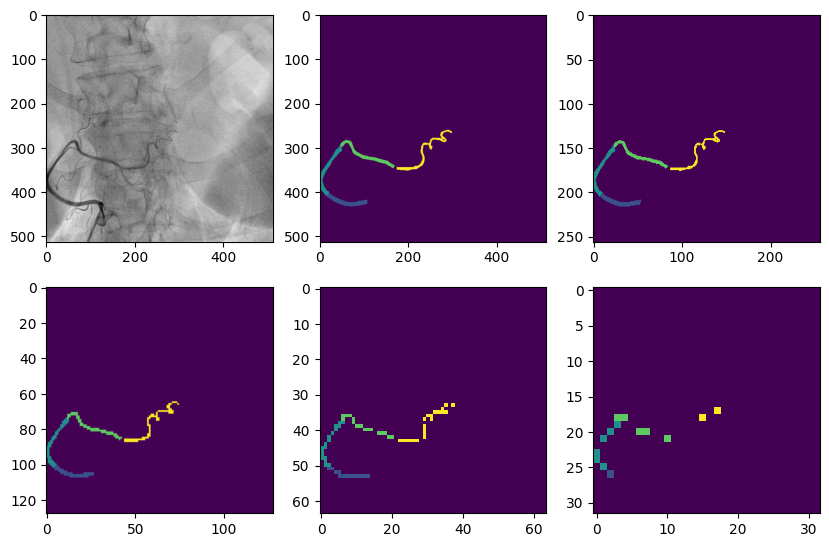

In [21]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)

for img,mask in train_loader:
    print(img.shape)
    print(mask[0].shape)
    ### binary check 
    index=0
    print(np.unique(mask[0][index].numpy()))
    ### abs check 
    img = to_rgb(img[index]).astype(np.uint8)
    plt.figure(figsize=(10,10))

    plt.subplot(3,3,1)
    plt.imshow(img,cmap="gray")
    for i in range(1,out_counts+1):
        plt.subplot(3,3,i+1)
        if(multi_args["just_binary_trining"]):
            # print(mask[i].shape)
            plt.imshow(mask[i-1][index][0].numpy(),cmap="gray")
        else:
            print(mask[i-1][index][0].shape)
            # colored_25 = draw_mask(image=img,mask=mask[i-1][index][0].numpy(),colors=colors)
            plt.imshow(mask[i-1][index][0])
            pass

    # plt.subplot(2,2,3)
    # plt.imshow(common_mask[index][0].numpy(),cmap="gray")
    # plt.subplot(2,2,4)
    # plt.imshow(rare_mask[index][0].numpy(),cmap="gray")
    break


In [22]:
class UnetP(torch.nn.Module):
    def __init__(self):
        super(UnetP,self).__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name="resnet50",  
            encoder_weights="imagenet",  
            in_channels=3,               
            classes=2
        )
    def forward(self,x):
        return [self.model(x)]

class DoubleModel(torch.nn.Module):
    def __init__(self,binary_args,multi_args):
        super(DoubleModel,self).__init__()
        self.multi_type = multi_args["multi_type"]
        if(self.multi_type!="og"):
            binary_encoder = nnUnet(binary_args)
            binary_encoder.load_state_dict(
                torch.load("/kaggle/input/binary-model/pytorch/default/1/model.pth"))
            self.binary_encoder = freeze_binary_encoder(binary_encoder)
            self.binary_encoder.deep_super_vision=False

            with torch.no_grad():
                for i in range(len(self.binary_encoder.decoders)):
                    self.binary_encoder.decoders[i].dsv = False

        self.encoder = nnUnet(multi_args)

    def train(self,mode=True):
        super(DoubleModel,self).train(mode)
        if(self.multi_type!="og"):
            self.binary_encoder.eval()
        return self
    def forward(self,x):
        if(self.multi_type=="prob"):
            with torch.no_grad():
                pred_binary = self.binary_encoder(x)[0]
                pred_binary = F.softmax(pred_binary,dim=1)
                pred_binary_fg = pred_binary[:,1:]
                # new_mask = pred_binary_fg*x
                new_mask = torch.cat([pred_binary_fg,x],dim=1)
            # plt.figure(figsize=(20,10))
            # plt.subplot(1,4,1)
            # plt.imshow(x[0][0].cpu().numpy()[...,None],cmap="gray")
            # plt.subplot(1,4,2)
            # print(pred_binary_fg[0][0].shape)
            # plt.imshow((pred_binary_fg[0][0].cpu()>=0.5).int().numpy(),cmap="gray")
            # plt.subplot(1,4,3)
            # print(new_mask.shape)
            # plt.imshow(pred_binary_fg[0][0].cpu().numpy(),cmap="gray")
            # plt.subplot(1,4,4)
            # print(new_mask.shape)
            # plt.imshow(new_mask[0][0].cpu().numpy(),cmap="gray")
        elif(self.multi_type=="binray"):
            with torch.no_grad():
                pred_binary = self.binary_encoder(x)[0]
                pred_binary = F.softmax(pred_binary,dim=1)
                pred_binary_fg = pred_binary[:,1:]
                new_mask = (pred_binary>=0.5).float()
        else:
            new_mask = x

        return self.encoder(new_mask)


# In[9]:


# model = DoubleModel(
#     binary_args=binary_args,
#     multi_args=multi_args
# ).to(multi_args["device"])
# for img,masks in train_loader:
#     preds = model(img.to(multi_args["device"]))
#     break


# In[10]:

In [23]:
# model = SwinEncoder(args).to(args["device"])
# model = UnetP().to(args["device"])
model = DoubleModel(
    binary_args=binary_args,
    multi_args=multi_args
).to(multi_args["device"])

loss_fn = MainLossFn(multi_args)

# optimizer = torch.optim.Adam(model.encoder.parameters(), lr=multi_args["lr"])
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=multi_args["momentum"],
    lr=multi_args["lr"],
    nesterov=True,
    weight_decay=multi_args["weight_decay"]
)
# optimizer = torch.optim.SGD(
#     model.encoder.parameters(),
#     momentum=multi_args["momentum"],
#     lr=multi_args["lr"],
#     nesterov=True,
#     weight_decay=multi_args["weight_decay"]
# )
# optimizer = torch.optim.AdamW(
#     model.encoder.parameters(), 
#     lr=args["lr"], 
#     betas=(0.9, 0.999), 
#     eps=1e-08, 
#     weight_decay=args["weight_decay"]
# )
if(multi_args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=multi_args["epcohs"],power=0.9)
else:
    lr_sch = None

recorder = HistoryRecorder(losses_keys=losses_keys,
                           class_maps =class_map,class_count=multi_args["class_count"])

best_model =trainer(
    args=multi_args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)
# ls = torch.rand(2,3,448,448).to("cuda")

number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  2
number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  26
loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

--- Total Norm ---
tensor(2.7404, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.6369, device='cuda:0')
----------------------

current lr : 0.01
train ==> epcoh (0)
total loss : 3.0055799503326415 - dice loss : 1.8783368139266967 - CE loss : 0.22544862574338914

train avg metrics for epoch 0 :
avg dice : 0.0036839660832786035 - avg precision : 0.0057578488523722625 - avg recall : 0.003970434312054749
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 2.8445066928863527 - dice loss : 1.8516458654403687 - CE loss : 0.1985721617937088

valid avg metrics for epoch 0 :
avg dice : 0.0032936146859526903 - avg precision : 0.001961195021867752 - avg recall : 0.010273019075393677
------------------------------------------------------------
New Best! : dice = 0.003293614601716399


  0%|          | 0/125 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(1.1057, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.8721, device='cuda:0')
----------------------

current lr : 0.0002283
train ==> epcoh (197)
total loss : 1.097709268093109 - dice loss : 0.993012038230896 - CE loss : 0.020939450077712536

train avg metrics for epoch 197 :
avg dice : 0.6694988536838423 - avg precision : 0.5696236550807953 - avg recall : 0.8279242849349976
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (197)
total loss : 1.5681328964233399 - dice loss : 1.143374035358429 - CE loss : 0.0849517622590065

valid avg metrics for epoch 197 :
avg dice : 0.46573581755171845 - avg precision : 0.43991150230169296 - avg recall : 0.5219218197464943
------------------------------------------------------------


  0%|          | 0/125 [00:00<?, ?it/s]

--- Total Norm ---
tensor(1.2611, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.3312, device='cuda:0')
----------------------

--- Total Norm ---
tensor(0.8907, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4570, device='cuda:0')
----------------------

--- Total Norm ---
tensor(1.2343, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7468, device='cuda:0')
----------------------

current lr : 0.0001585
train ==> epcoh (198)
total loss : 1.0854354705810547 - dice loss : 0.9814674081802368 - CE loss : 0.020793612822890283

train avg metrics for epoch 198 :
avg dice : 0.669845538139714 - avg precision : 0.5667839646339417 - avg recall : 0.8391837215423584
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (198)
total loss : 1.5556494617462158 - dice loss : 1.1364947605133056 - CE loss : 0.08383094616234303

valid avg metrics for epoch 198 :
avg dice : 0.46542336255322525 - avg precision : 0.4348342284560204 - avg recall : 0.5266015183925629
------------

  0%|          | 0/125 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.9315, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.5928, device='cuda:0')
----------------------

current lr : 8.493e-05
train ==> epcoh (199)
total loss : 1.1092098240852355 - dice loss : 0.9985139837265015 - CE loss : 0.022139166295528413

train avg metrics for epoch 199 :
avg dice : 0.6617421889308822 - avg precision : 0.5601284086704255 - avg recall : 0.8288806581497192
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (199)
total loss : 1.563883023262024 - dice loss : 1.1402029776573182 - CE loss : 0.08473600767552852

valid avg metrics for epoch 199 :
avg dice : 0.4653327649832828 - avg precision : 0.4360561940073967 - avg recall : 0.5250561967492103
1 => dice : 0.8187308311462402 p : 0.7709916830062866 , r : 0.8727720975875854
2 => dice : 0.750525176525116 p : 0.7309484481811523 , r : 0.7711794376373291
3 => dice : 0.7558725476264954 p : 0.7082017660140991 , r : 0.8104240894317627
4 => dice : 0.6517709493637085 p : 0.55

Save Model
Saving Memory
Saving All Plots
Saving Examples
Saving Verbal Results


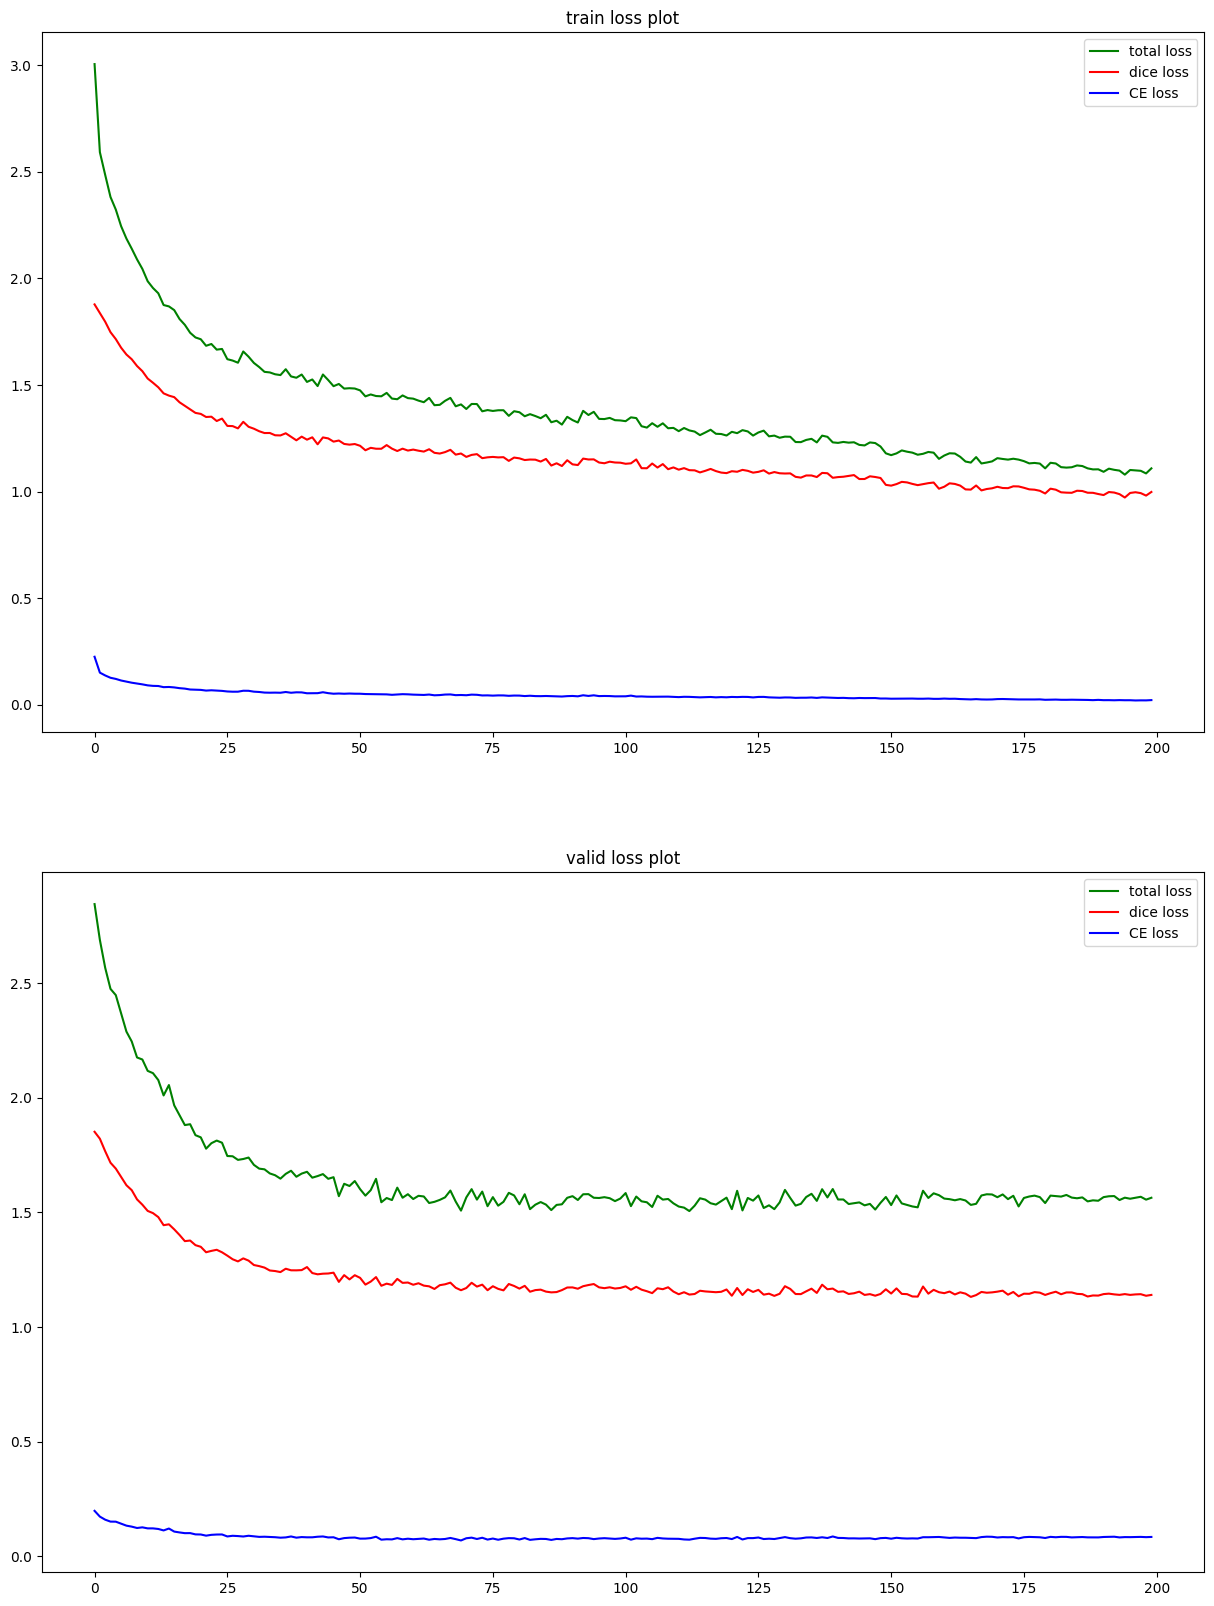

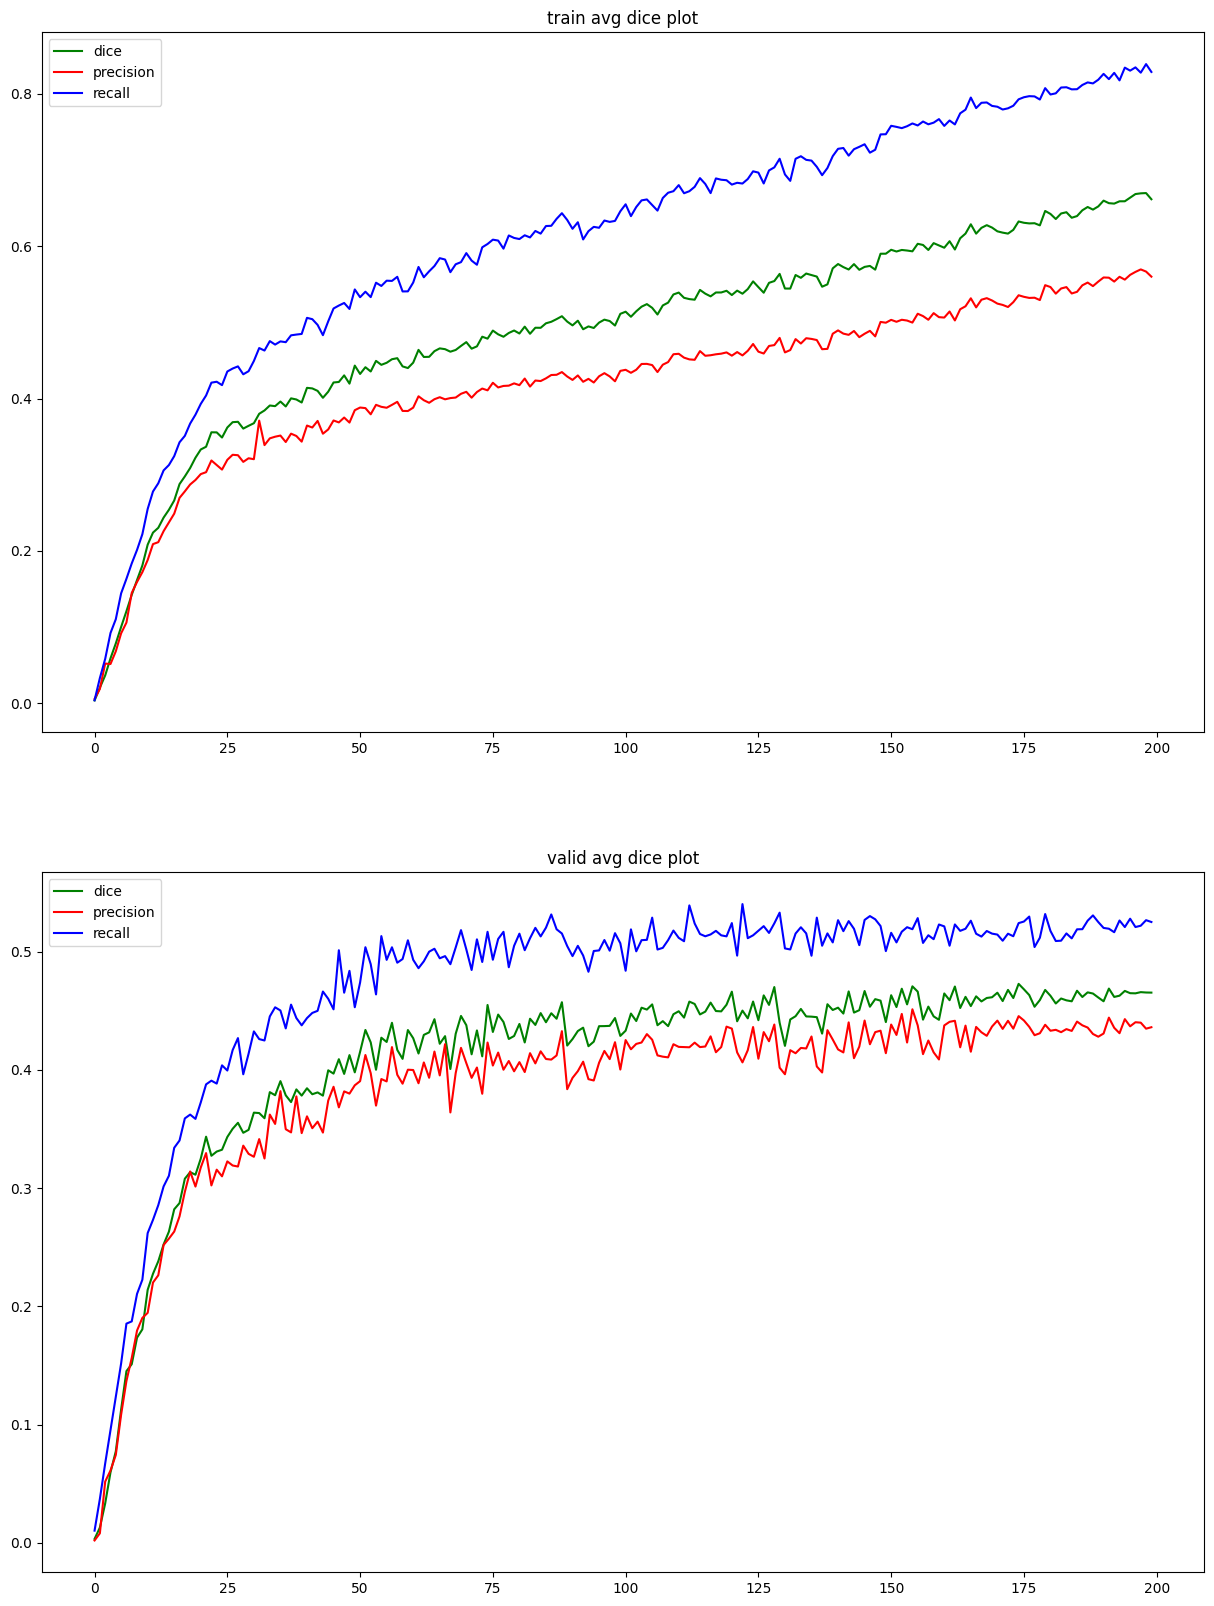

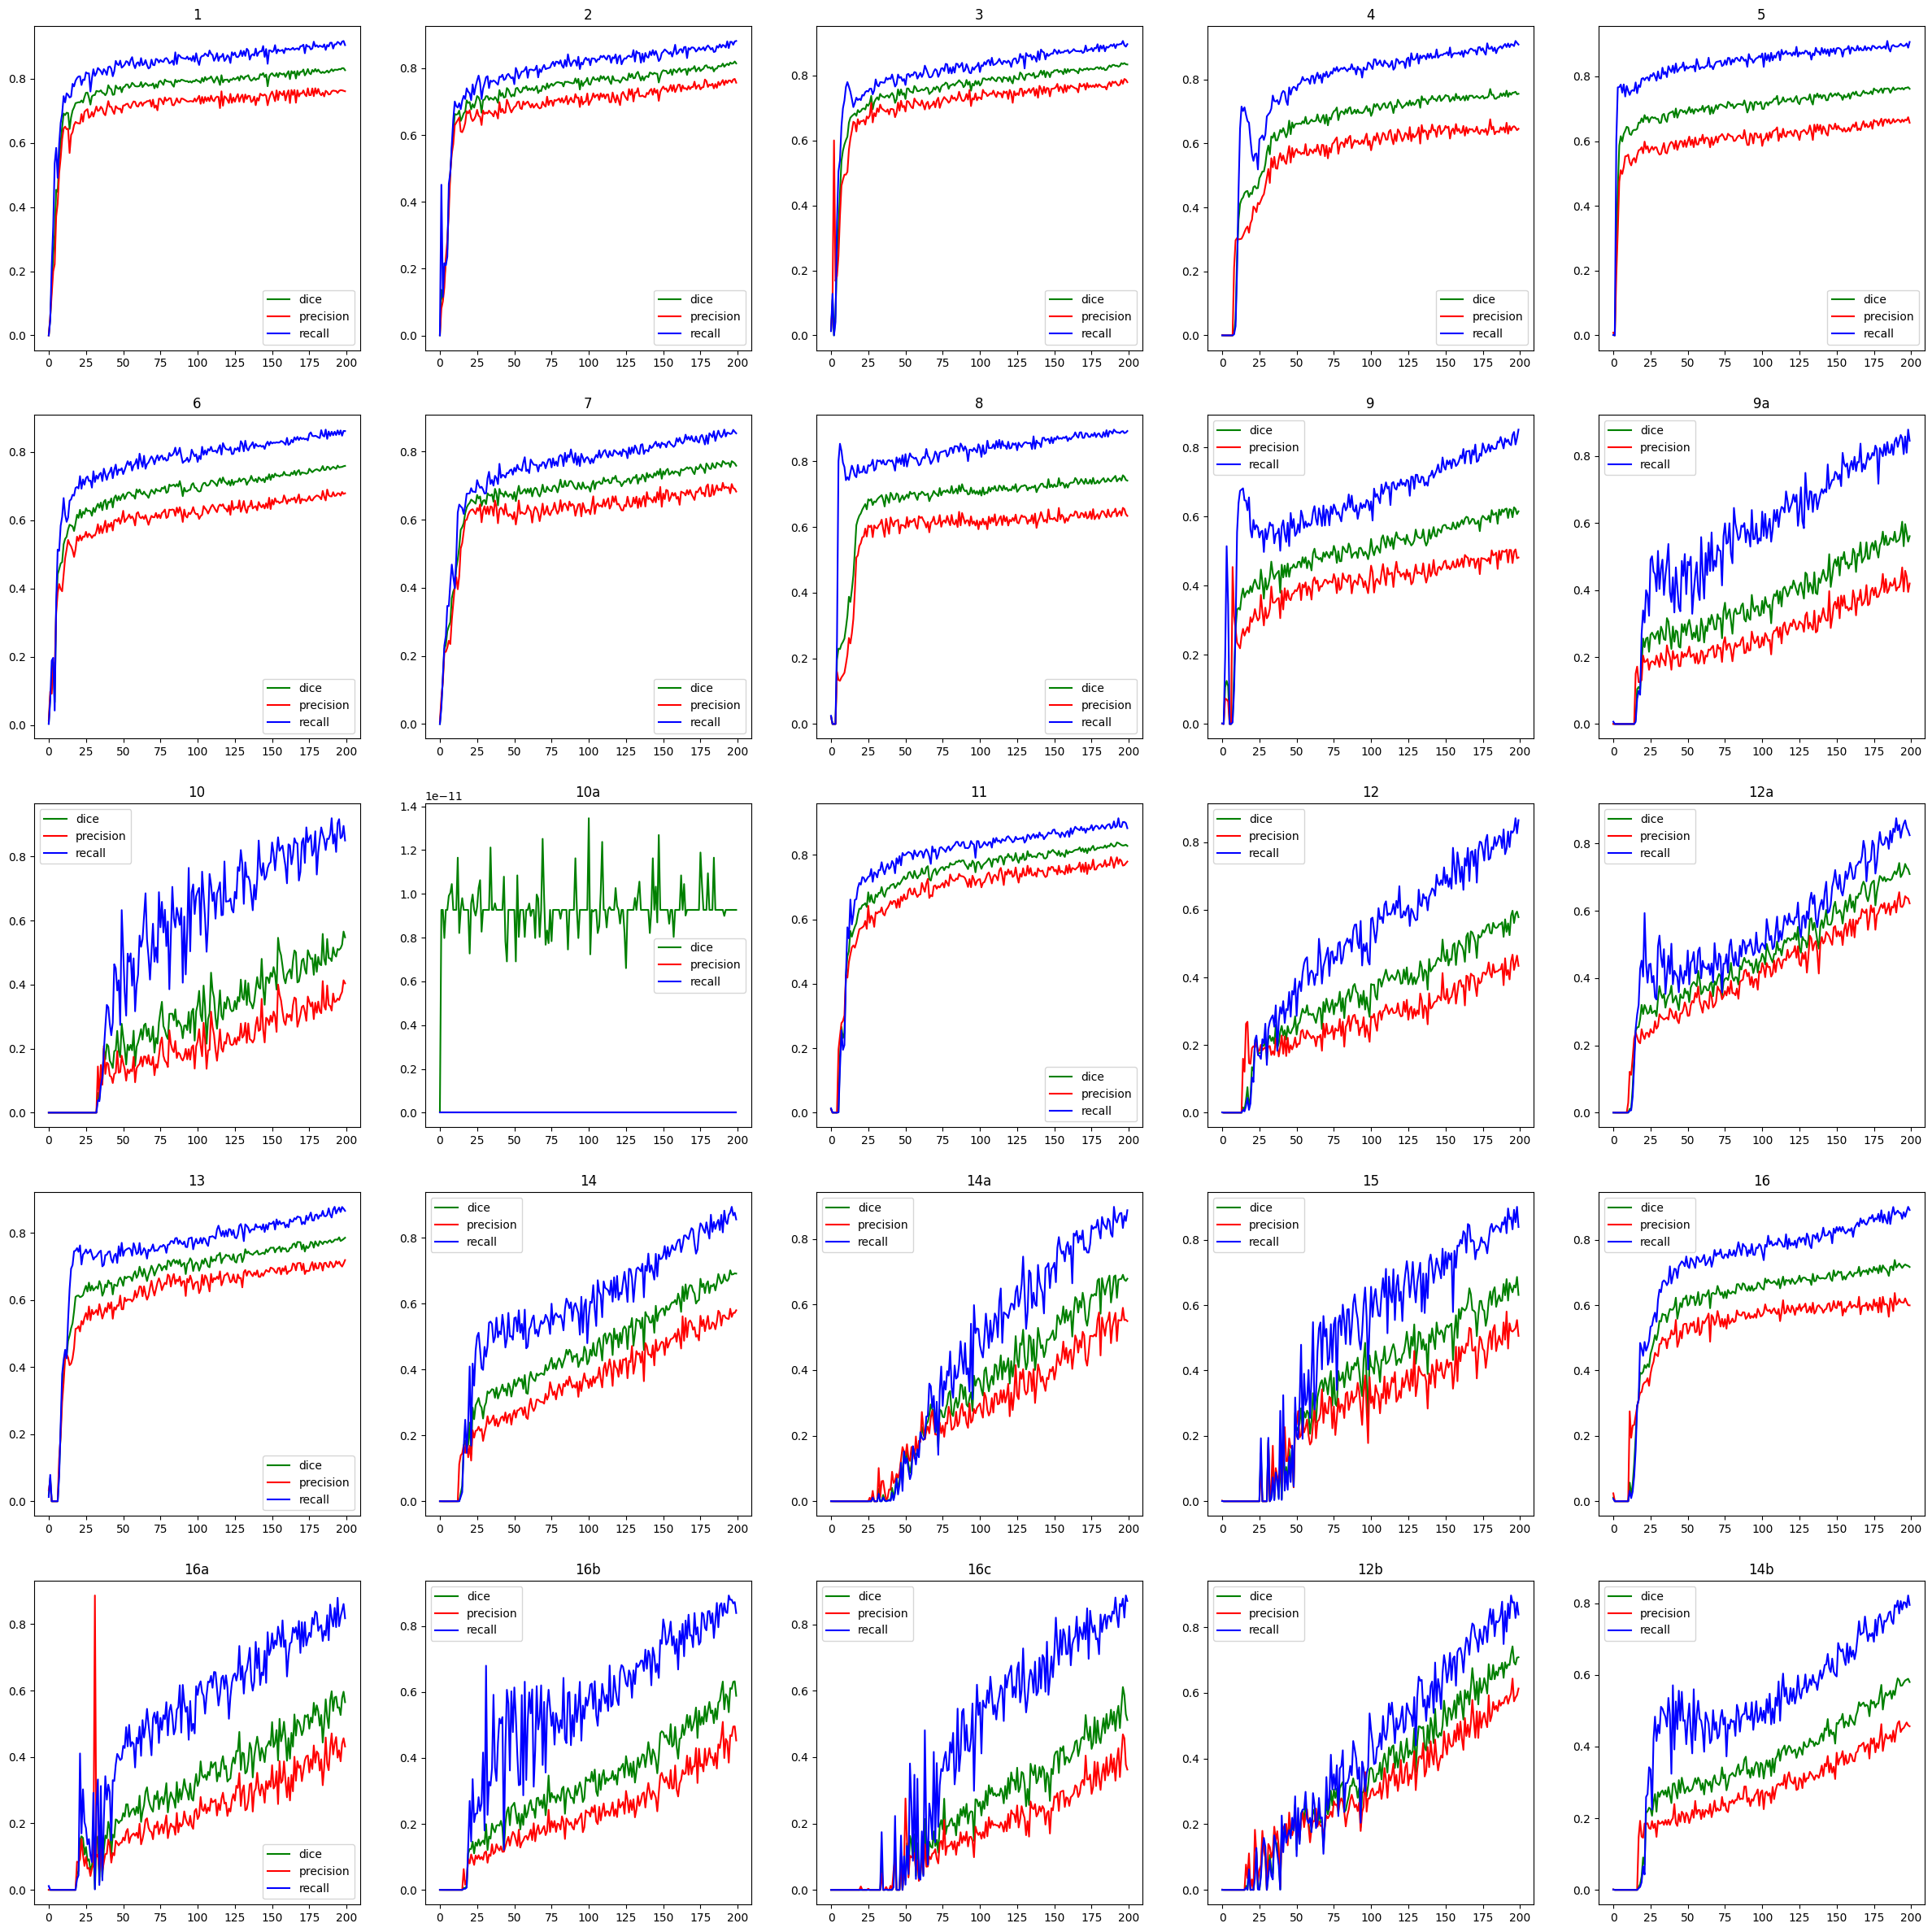

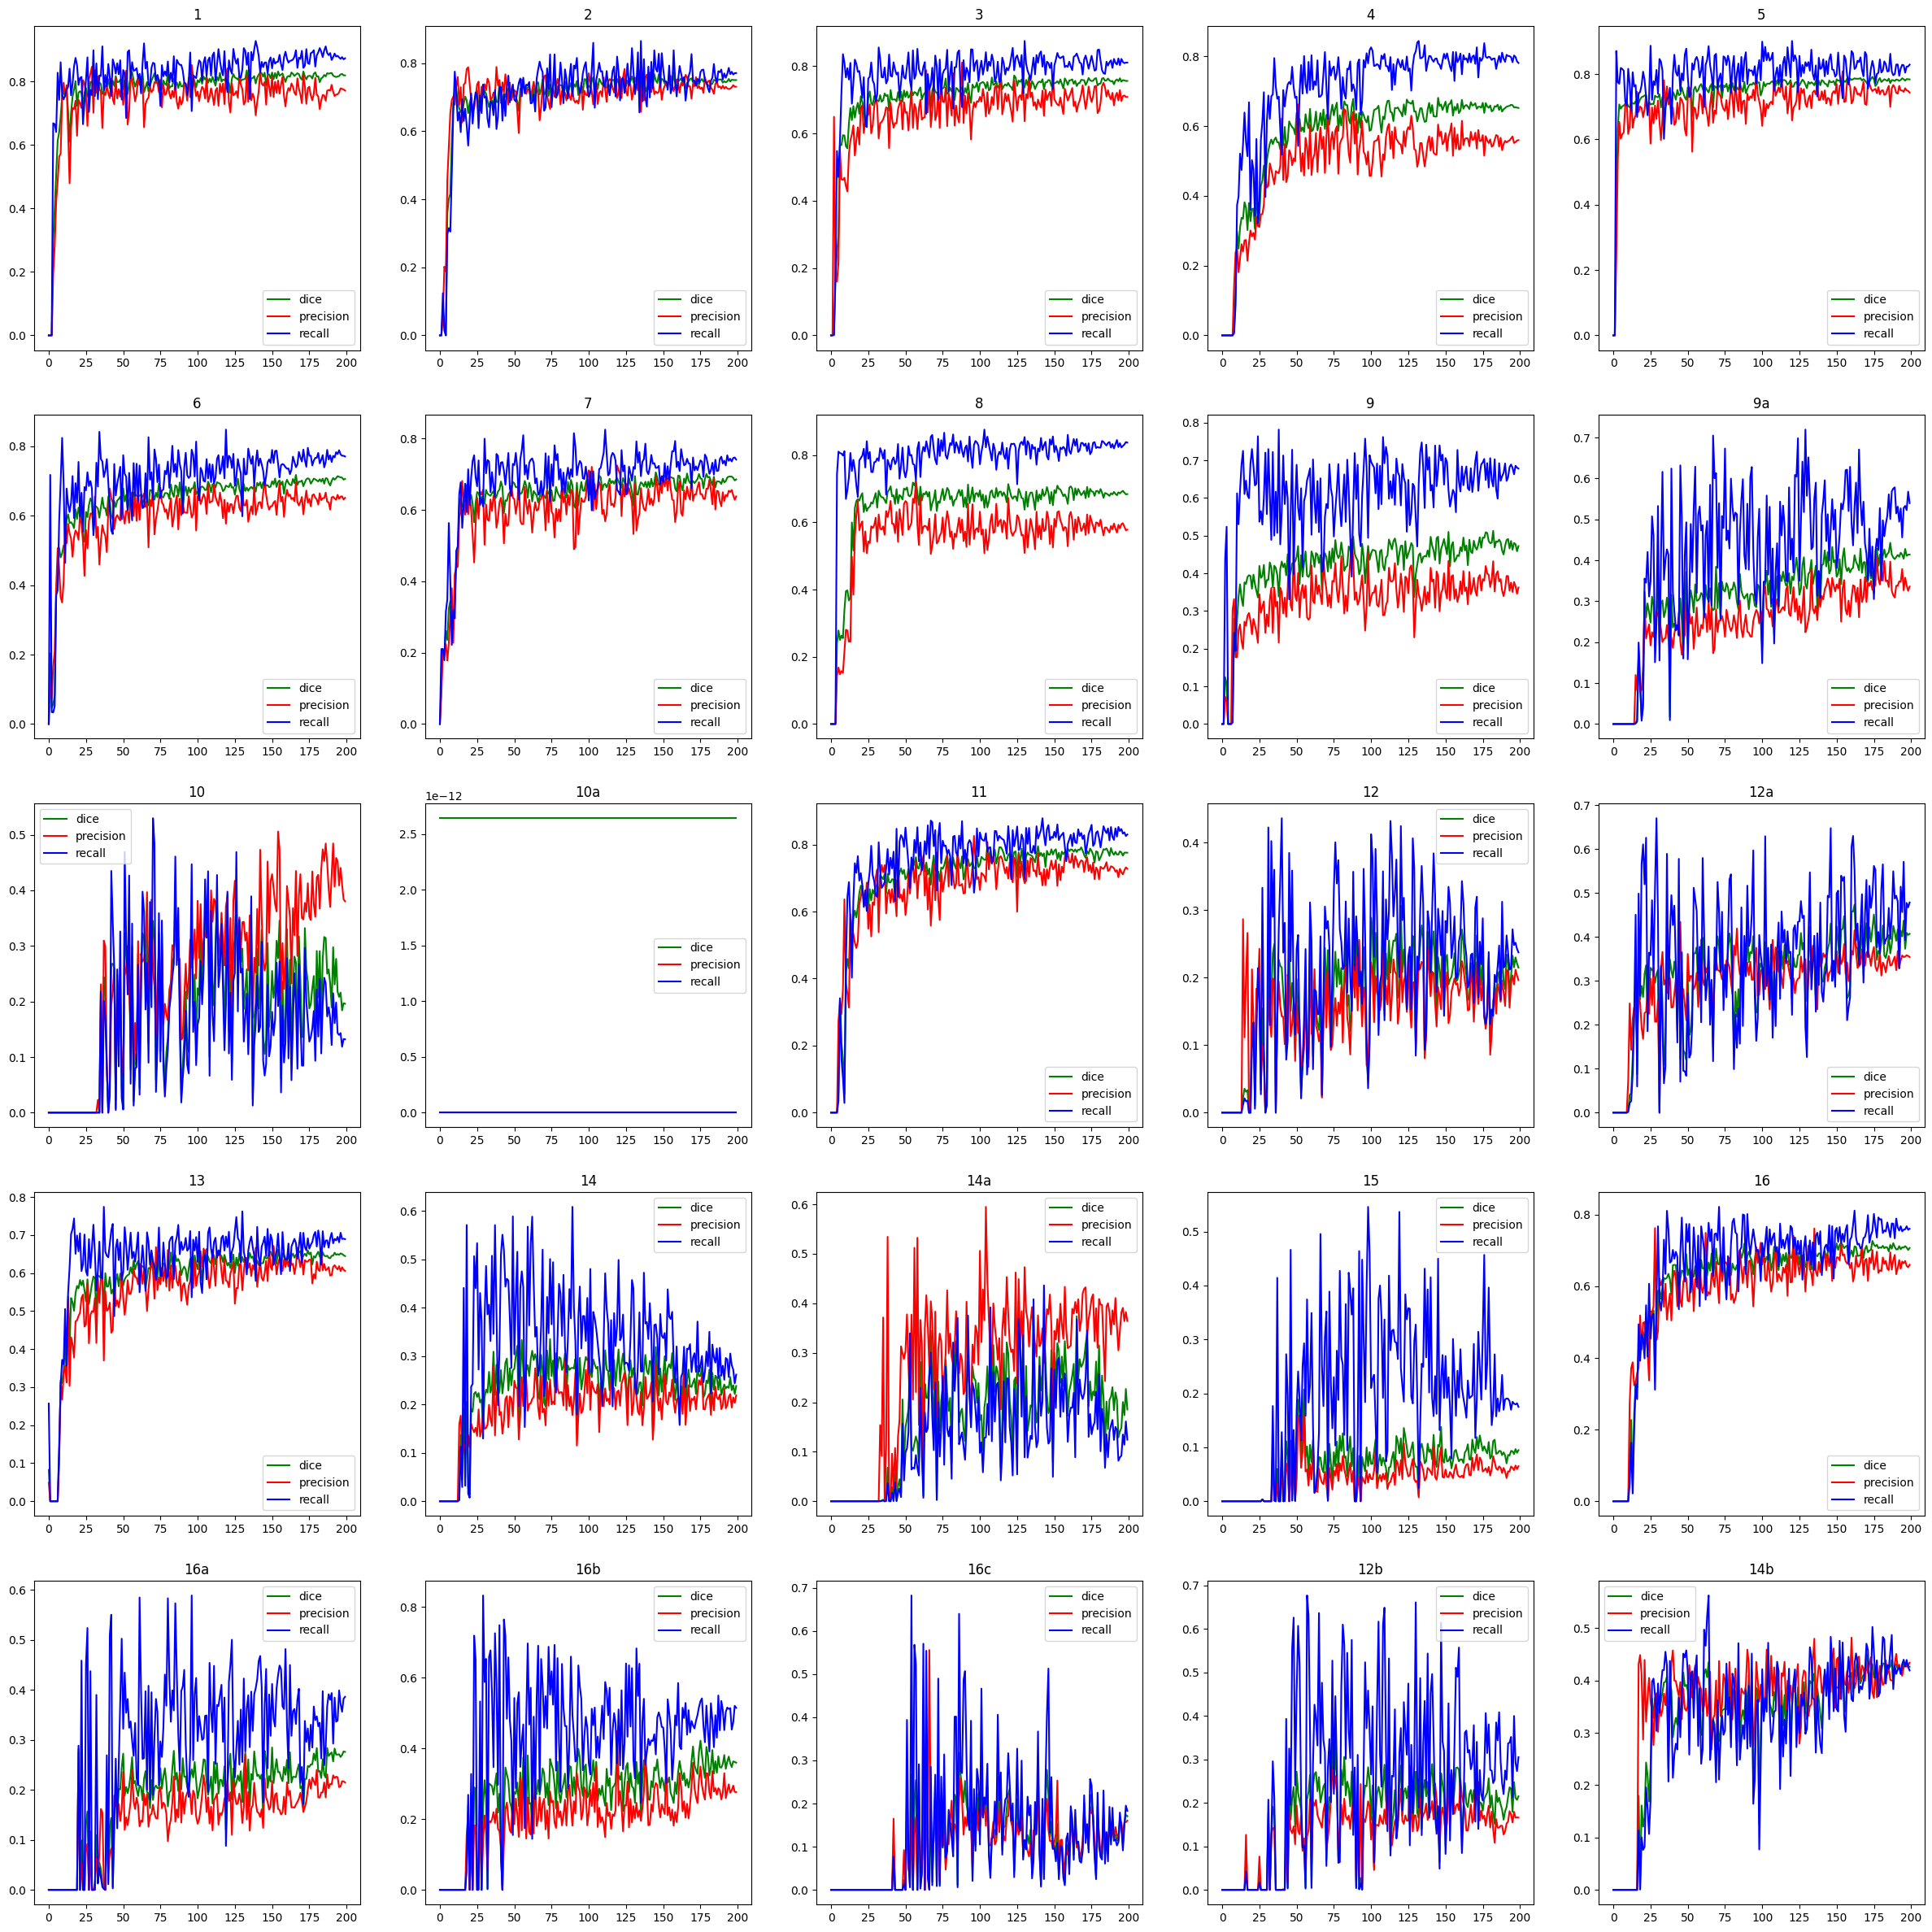

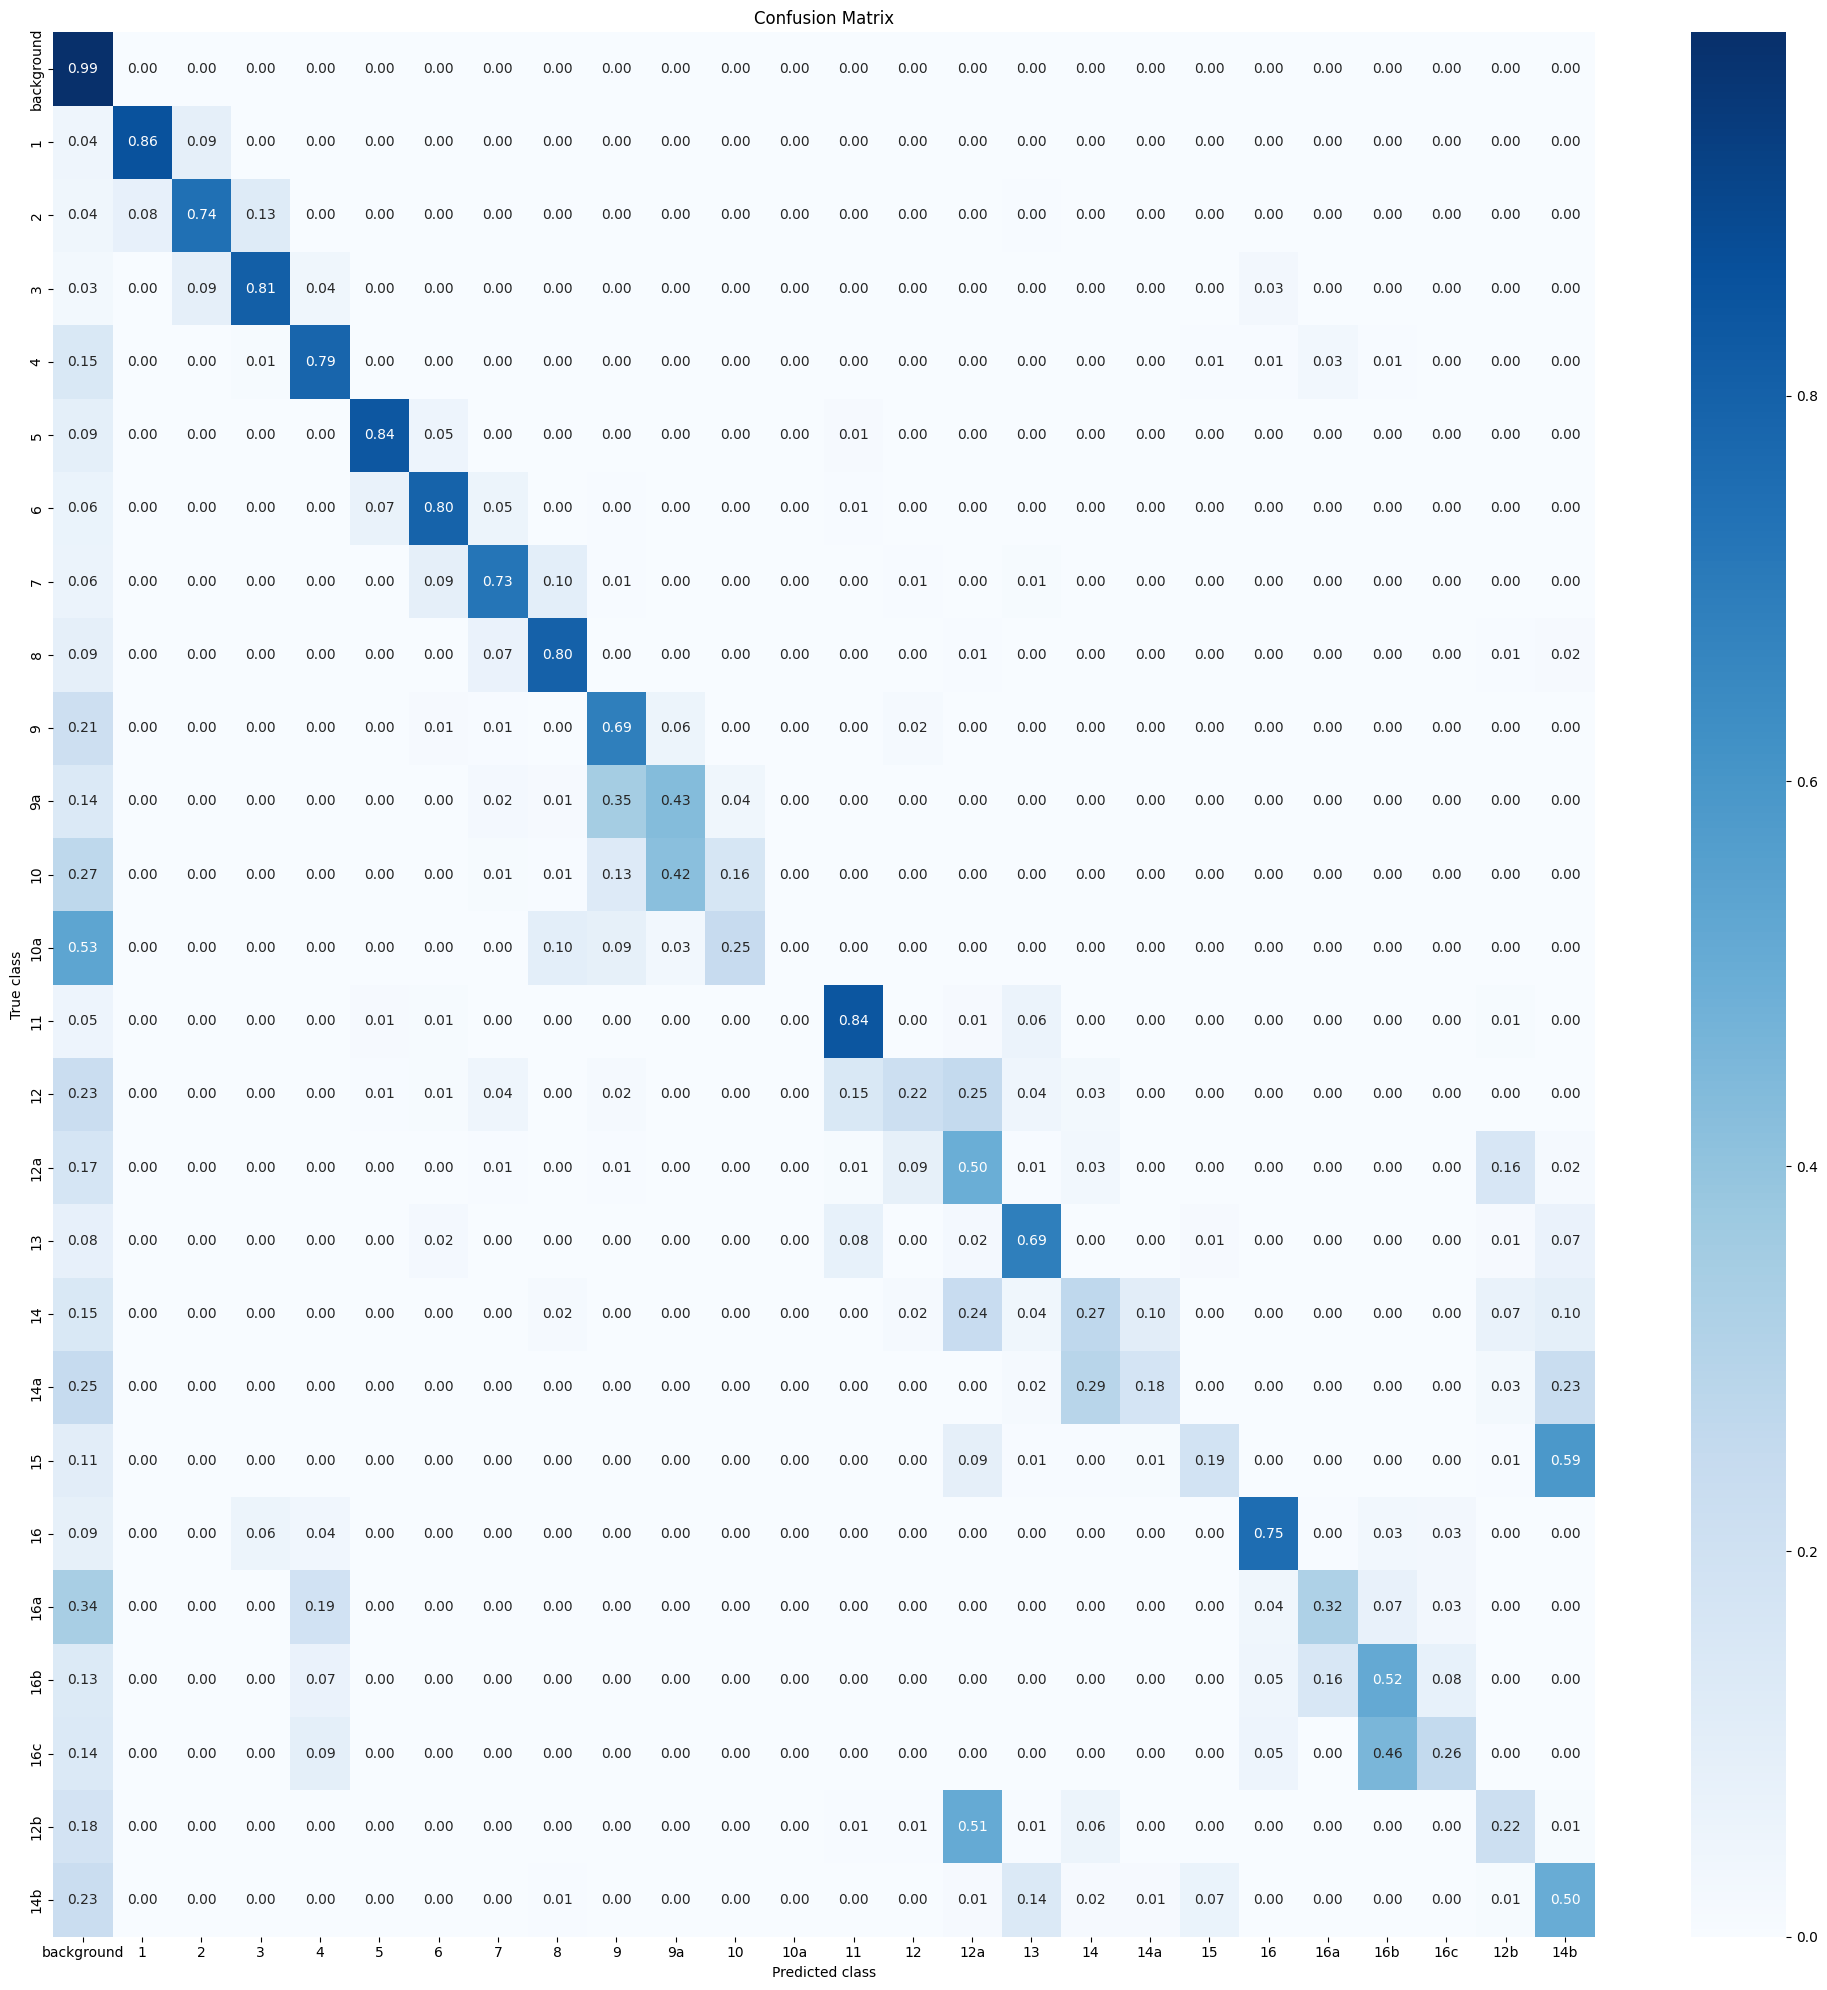

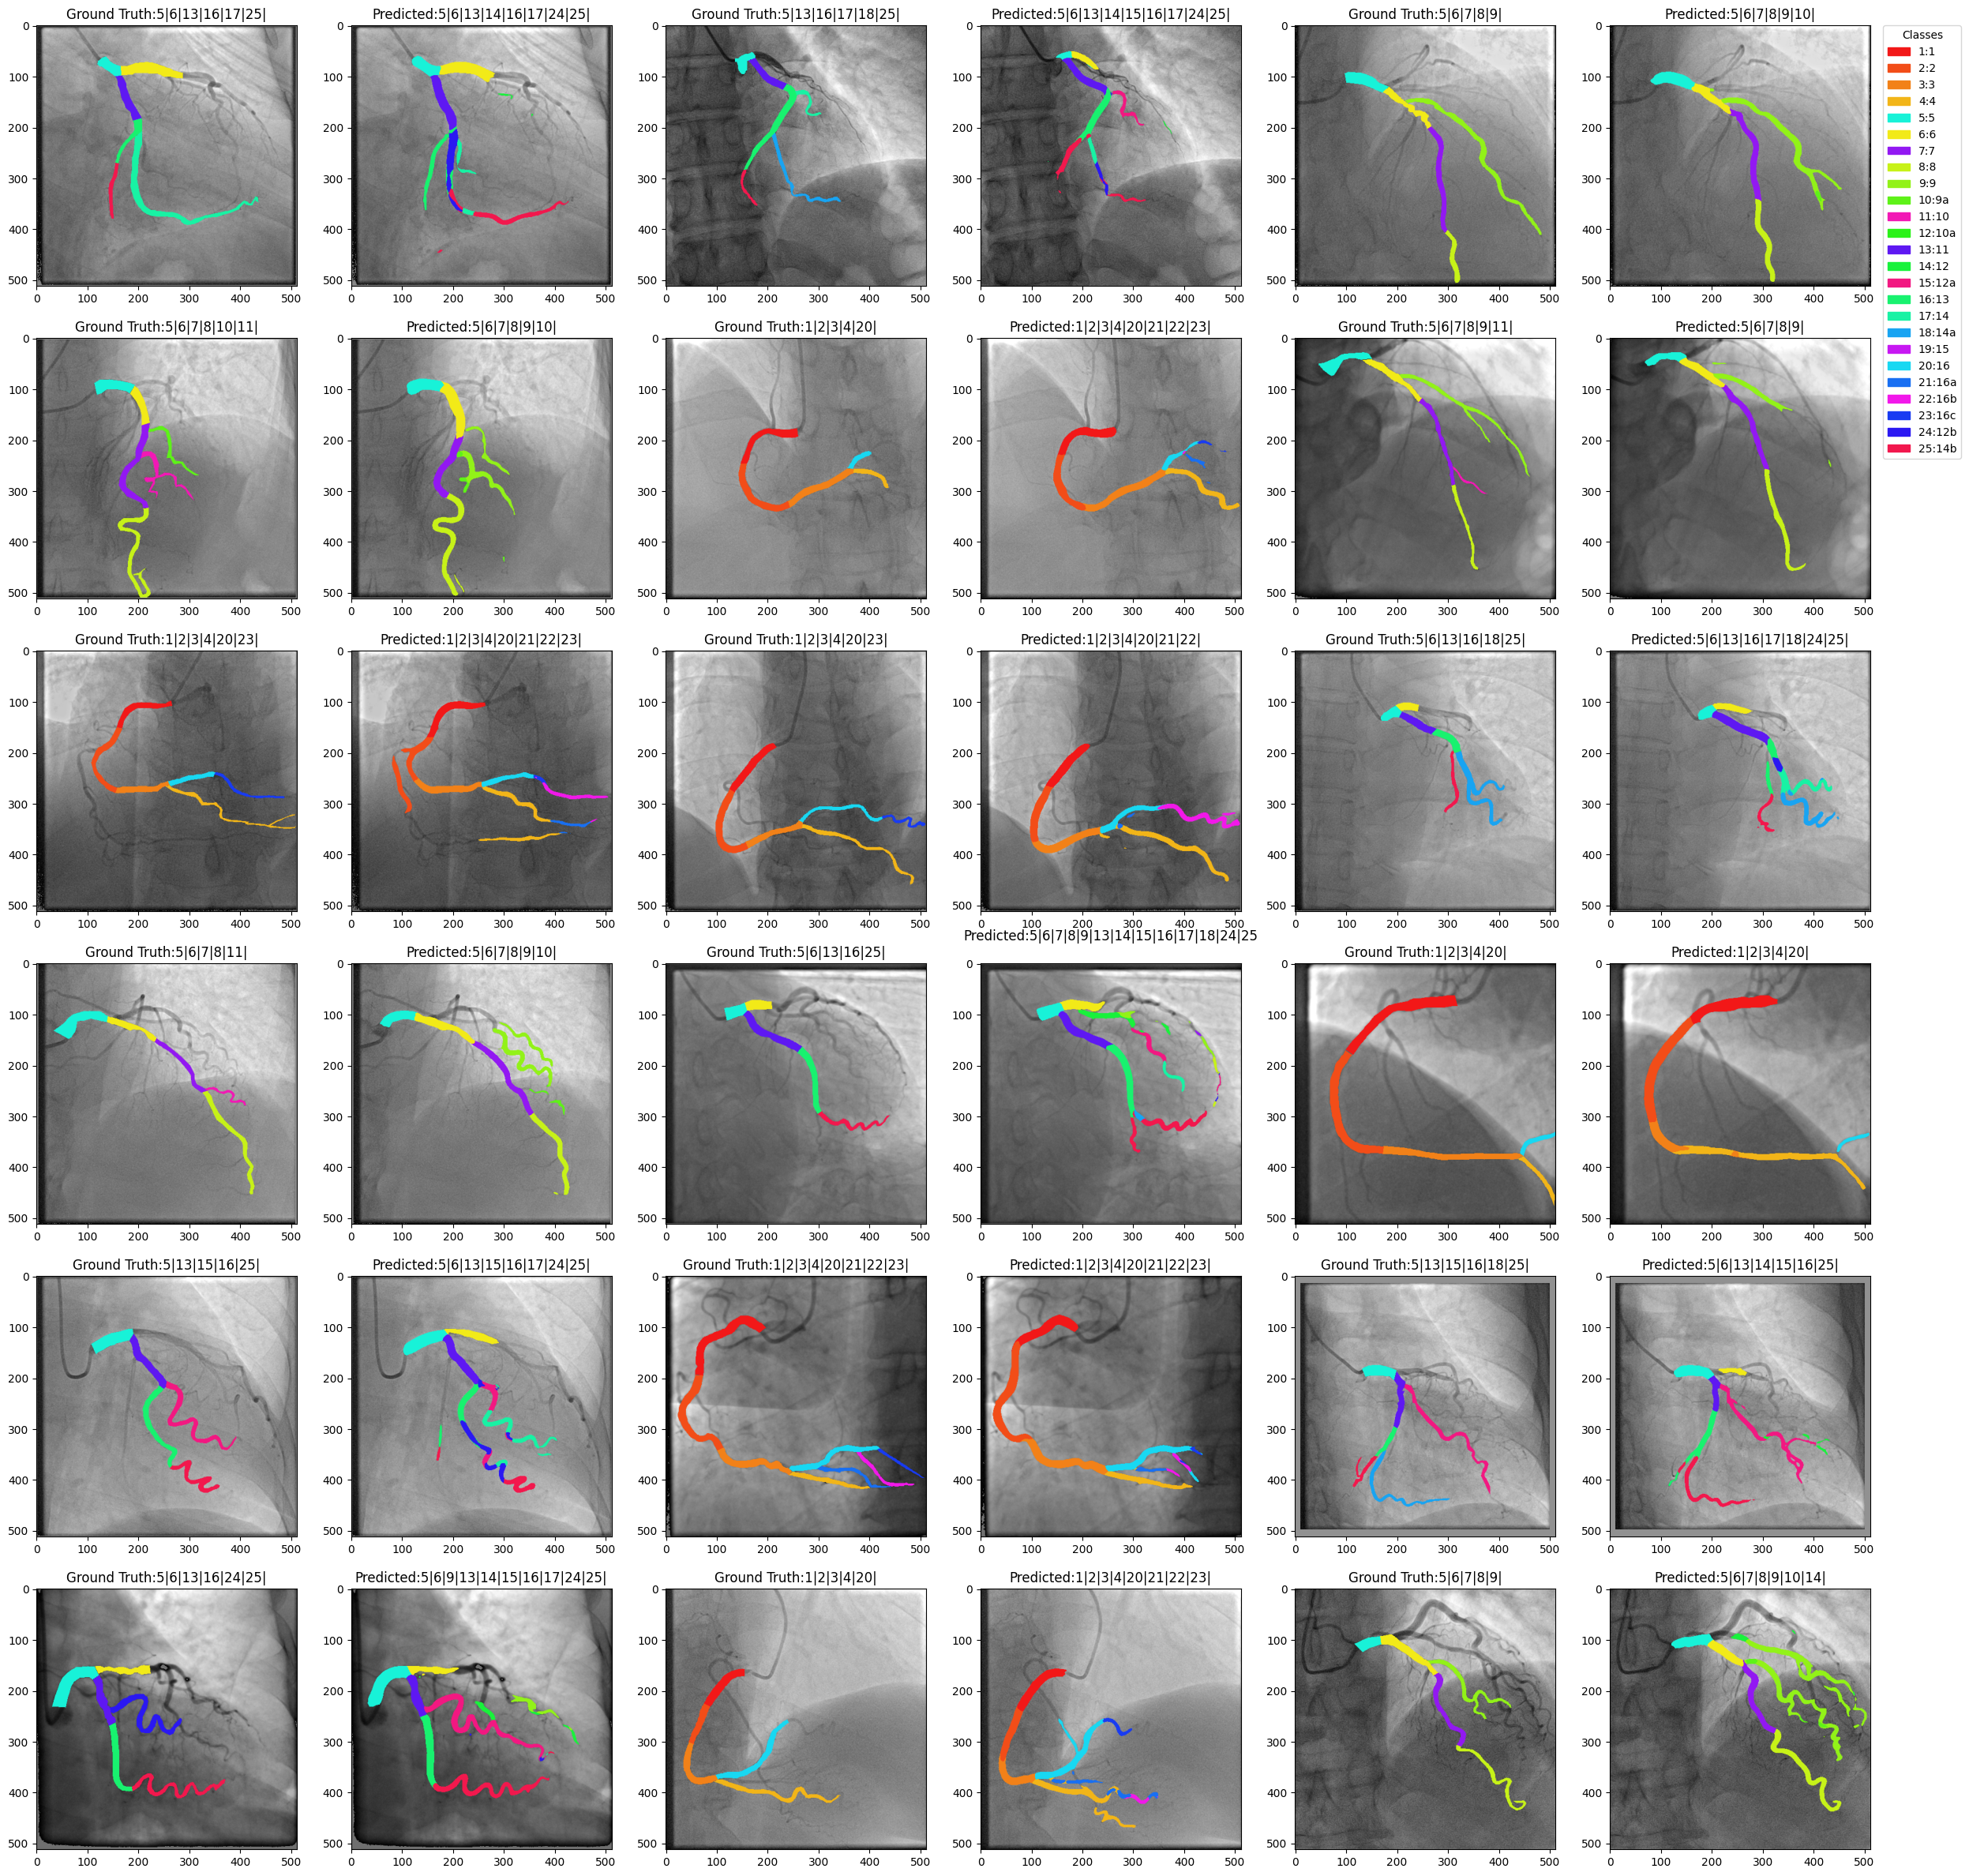

In [24]:
save_full_report(
    recorder= recorder , 
    output_base_path=multi_args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=multi_args,
    class_map=class_map,
    name=multi_args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
    just_binary_trining = multi_args["just_binary_trining"],
    use_amp = multi_args["use_amp"],
    binary_type = multi_args["binary_type"]
)


# In[ ]: